In [ ]:
# # Gõ dòng này vào cell đầu tiên và bấm Run (Shift + Enter)
# get_ipython().run_line_magic('run', '../_setup.py')

In [2]:
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from scipy.stats import pearsonr
from statsmodels.graphics.tsaplots import plot_acf
from pathlib import Path
from IPython.display import display

In [3]:
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"

### 1. Explore the following four time series: Bricks from aus_production, Lynx from pelt, GOOG_Close from gafa_stock, Demand from vic_elec.

- Use .info() to find out about the data in each series.
- What is the time interval of each series?
- Use plot_series() to produce a time plot of each series.
- For the last plot, modify the axis labels and title.

In [4]:
# Answer here 
Bricks = (
    pd.read_csv(DATA_DIR / "aus_production.csv", parse_dates=['ds'])
    [['ds', 'Bricks']]
    .assign(unique_id="unique_id")
    .rename(columns={'Bricks': 'y'})
)
Lynx = pd.read_csv(DATA_DIR / "pelt.csv", parse_dates=['ds'])
GOOG_CLose = pd.read_csv(DATA_DIR / "gafa_stock.csv", parse_dates=['ds'])
Demand = pd.read_csv(DATA_DIR / "vic_elec.csv", parse_dates=['ds'])

print(Bricks.info())
print(Lynx.info())
print(GOOG_CLose.info())
print(Demand.info())

datasets = {
    "Bricks": Bricks,
    "Lynx": Lynx,
    "GOOG_Close": GOOG_CLose,
    "Demand": Demand
}

for name, df in datasets.items():
    # Sắp xếp theo thời gian để đảm bảo tính toán đúng
    df = df.sort_values('ds')
    
    # Tính khoảng cách giữa các mốc thời gian liên tiếp
    time_diffs = df['ds'].diff().value_counts()
    
    print(f"--- Khoảng thời gian của {name} ---")
    print(time_diffs.head(1)) # Hiển thị khoảng cách xuất hiện nhiều nhất
    print("\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 218 entries, 0 to 217
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   ds         218 non-null    datetime64[ns]
 1   y          198 non-null    float64       
 2   unique_id  218 non-null    object        
dtypes: datetime64[ns](1), float64(1), object(1)
memory usage: 5.2+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 182 entries, 0 to 181
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   unique_id  182 non-null    object        
 1   ds         182 non-null    datetime64[ns]
 2   y          182 non-null    int64         
dtypes: datetime64[ns](1), int64(1), object(1)
memory usage: 4.4+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30192 entries, 0 to 30191
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     -

--- Đang hiển thị visual cho: Bricks ---


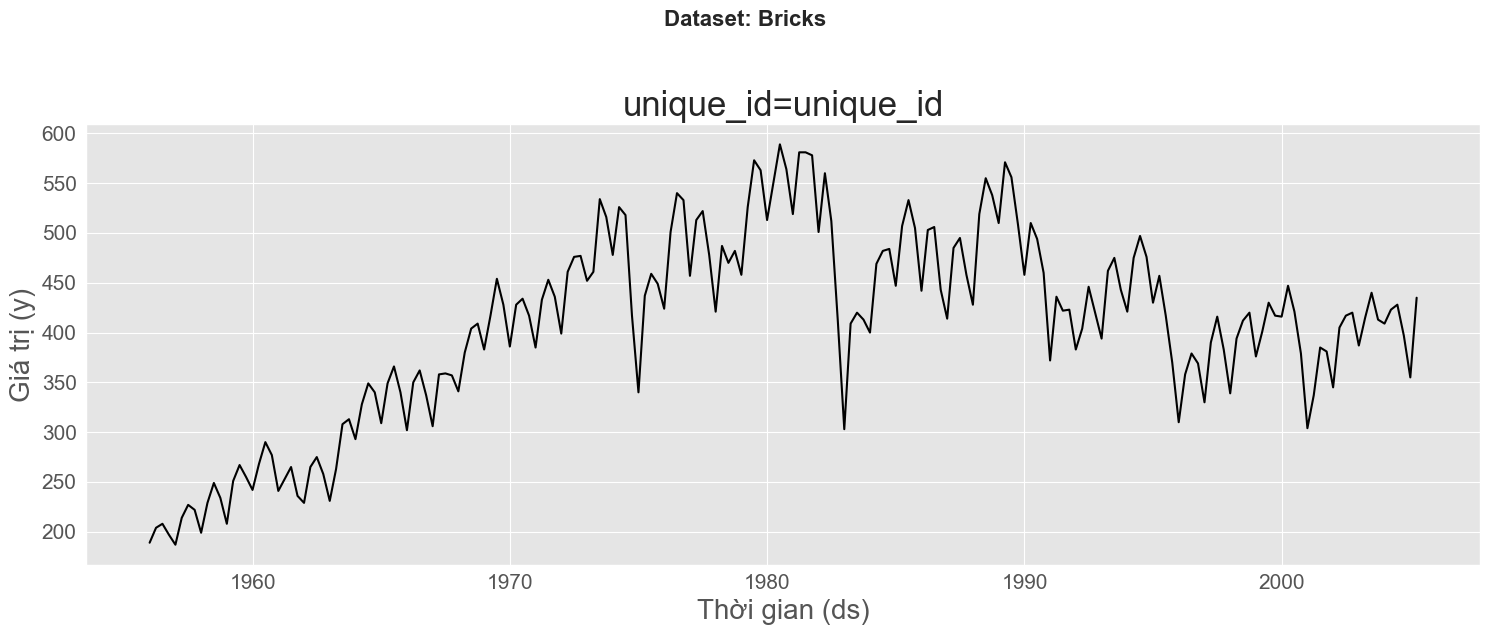

--- Đang hiển thị visual cho: Lynx ---


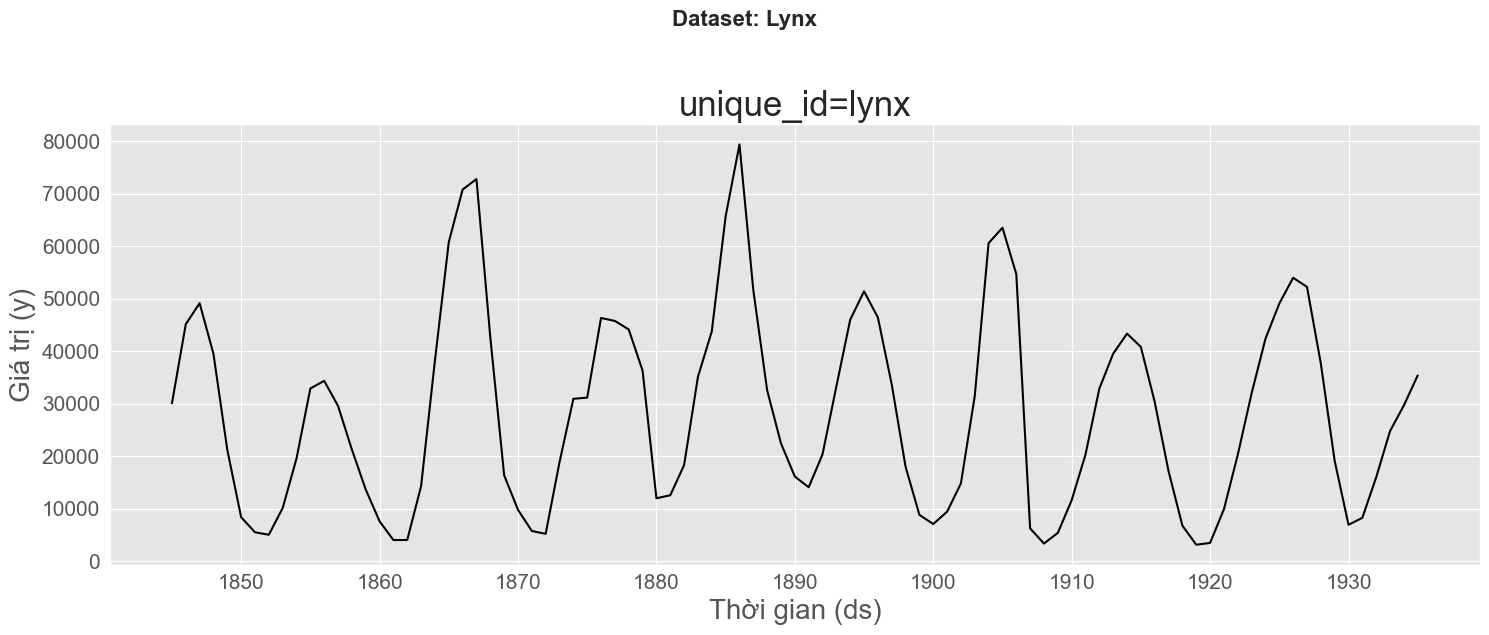

--- Đang hiển thị visual cho: GOOG_Close ---


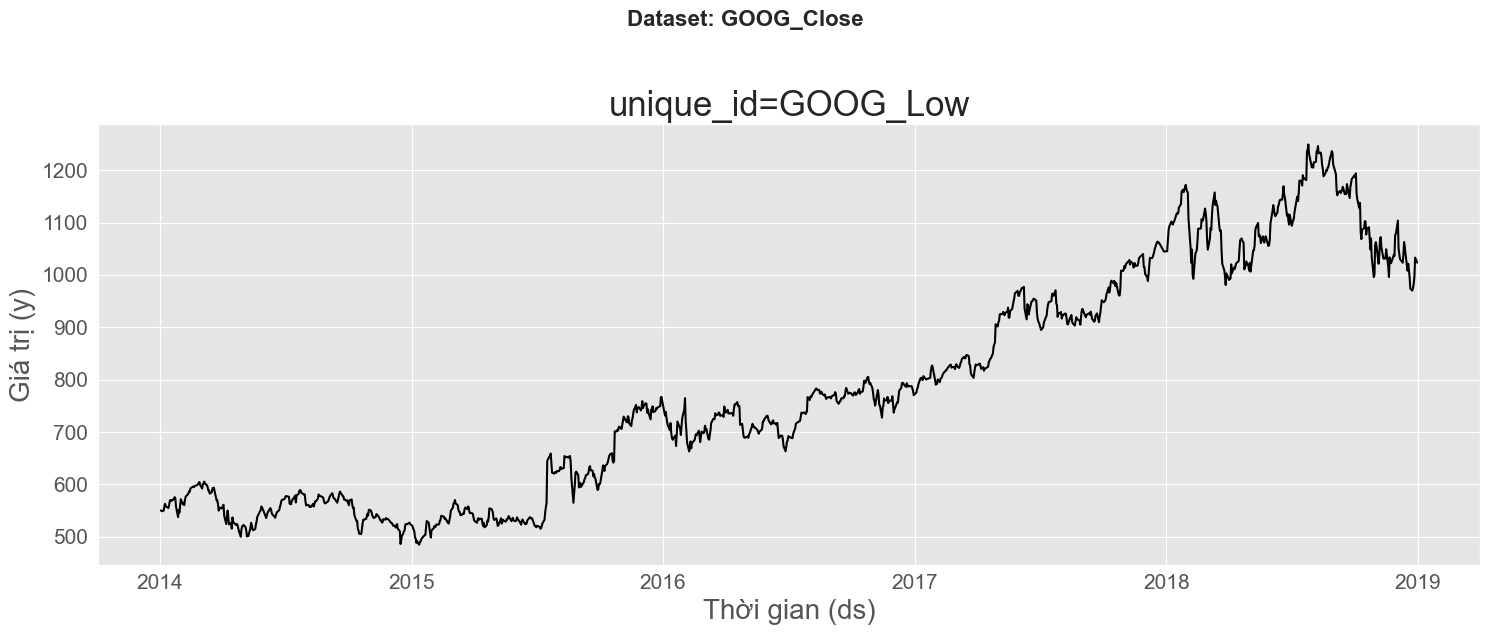

--- Đang hiển thị visual cho: Demand ---


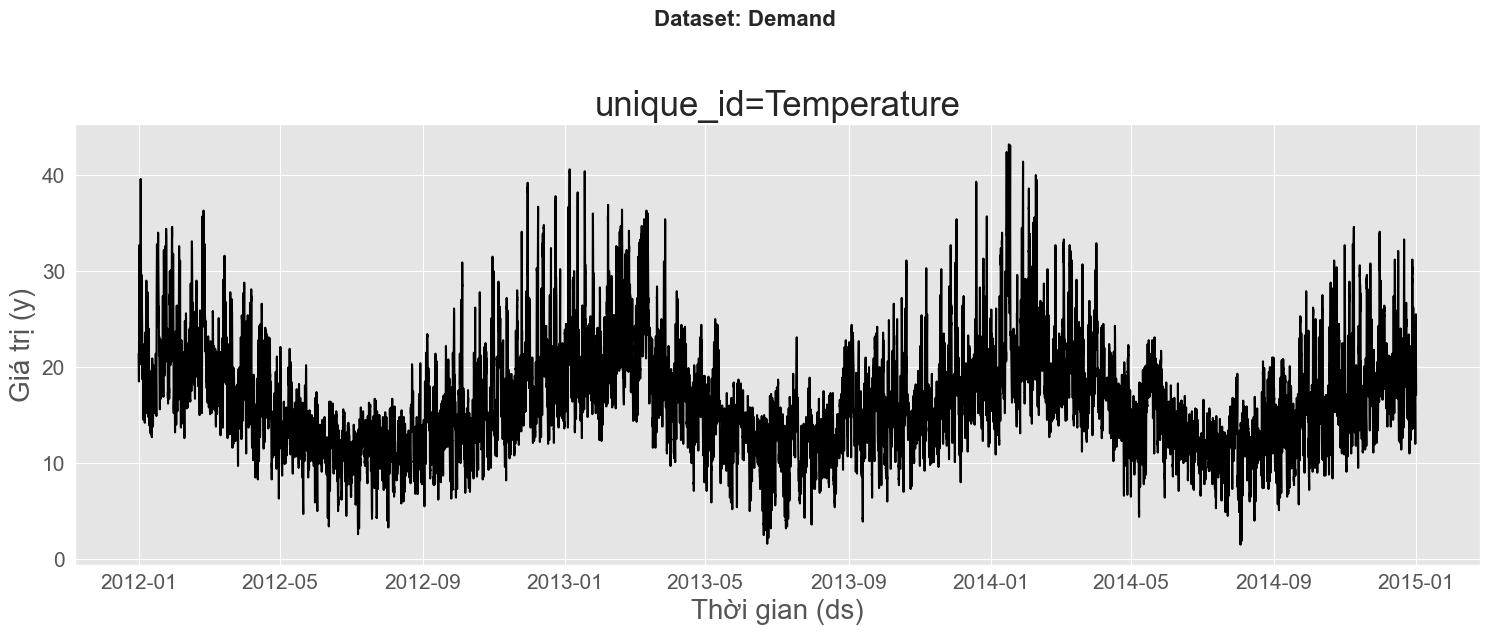

In [5]:
def plot_each_series(x):
    for name, df in x.items():
        print(f"--- Đang hiển thị visual cho: {name} ---")
        
        # Gọi Nixtla để lấy đối tượng Figure
        fig = plot_series(
            df=df, 
            id_col="unique_id", 
            time_col="ds", 
            target_col="y",
            engine="matplotlib"
        )
        
        # 1. Thêm tiêu đề tổng cho cả cụm biểu đồ
        fig.suptitle(f"Dataset: {name}", fontsize=16, fontweight='bold', y=1.05)
        
        # 2. Duyệt qua từng biểu đồ con (axes) để thêm label
        for ax in fig.axes:
            ax.set_xlabel("Thời gian (ds)")
            ax.set_ylabel("Giá trị (y)")
            
        # 3. Tự động căn chỉnh để không bị dính chữ
        fig.tight_layout()
        
        # 4. Hiển thị đối tượng figure
        display(fig) 

# Chạy hàm
plot_each_series(datasets)

### 2. Use .loc[] or query() to find what days corresponded to the peak closing price for each of the four stocks in gafa_stock.

In [6]:
# Answer here

stocks = pd.read_csv(DATA_DIR / "gafa_stock.csv", parse_dates = ['ds'])

# filter records in Close group
stocks_close = stocks[stocks['unique_id'].str.endswith('Close')]

idx_peaks = stocks_close.groupby('unique_id')['y'].idxmax()
final_peaks = stocks_close.loc[idx_peaks, ['unique_id', 'ds', 'y']]
final_peaks

,unique_id,ds,y
21325,AAPL_Adj_Close,2018-10-03,230.275
16293,AAPL_Close,2018-10-03,232.070
22562,AMZN_Adj_Close,2018-09-04,2039.510
17530,AMZN_Close,2018-09-04,2039.510
23792,FB_Adj_Close,2018-07-25,217.500
18760,FB_Close,2018-07-25,217.500
25051,GOOG_Adj_Close,2018-07-26,1268.330
20019,GOOG_Close,2018-07-26,1268.330


### 3. Download the file tute1.csv from the book website, open it in Excel (or some other spreadsheet application), and review its contents. You should find four columns of information. Columns B through D each contain a quarterly series, labelled Sales, AdBudget and GDP. Sales contains the quarterly sales for a small company over the period 1981–2005. AdBudget is the advertising budget and GDP is the gross domestic product. All series have been adjusted for inflation. Construct time series plots of each of the three series.


--- Đang vẽ cột: Sales ---


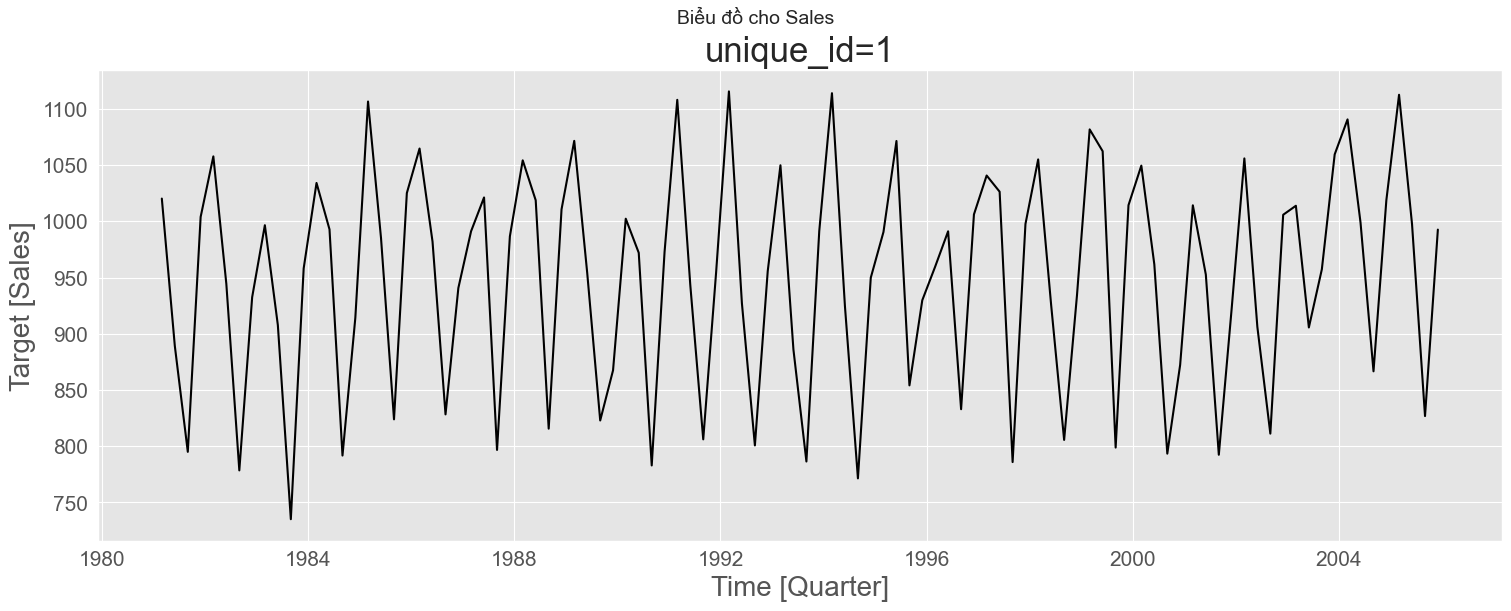

--- Đang vẽ cột: AdBudget ---


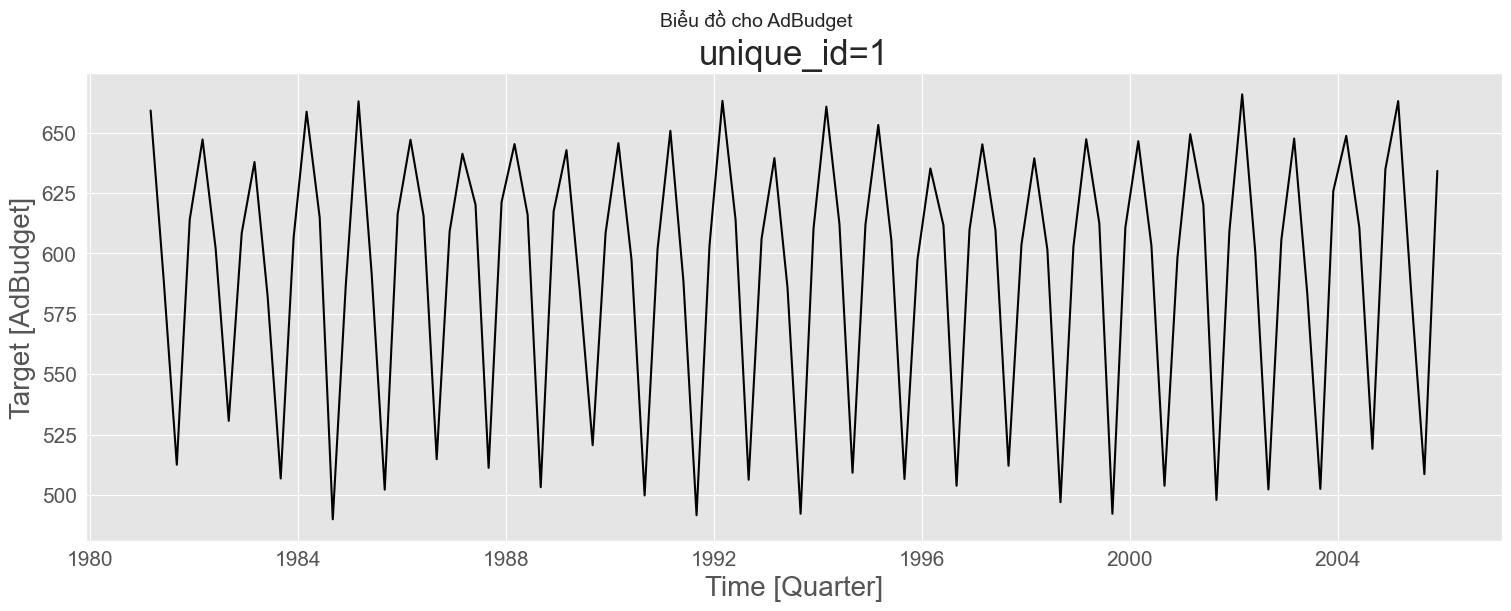

--- Đang vẽ cột: GDP ---


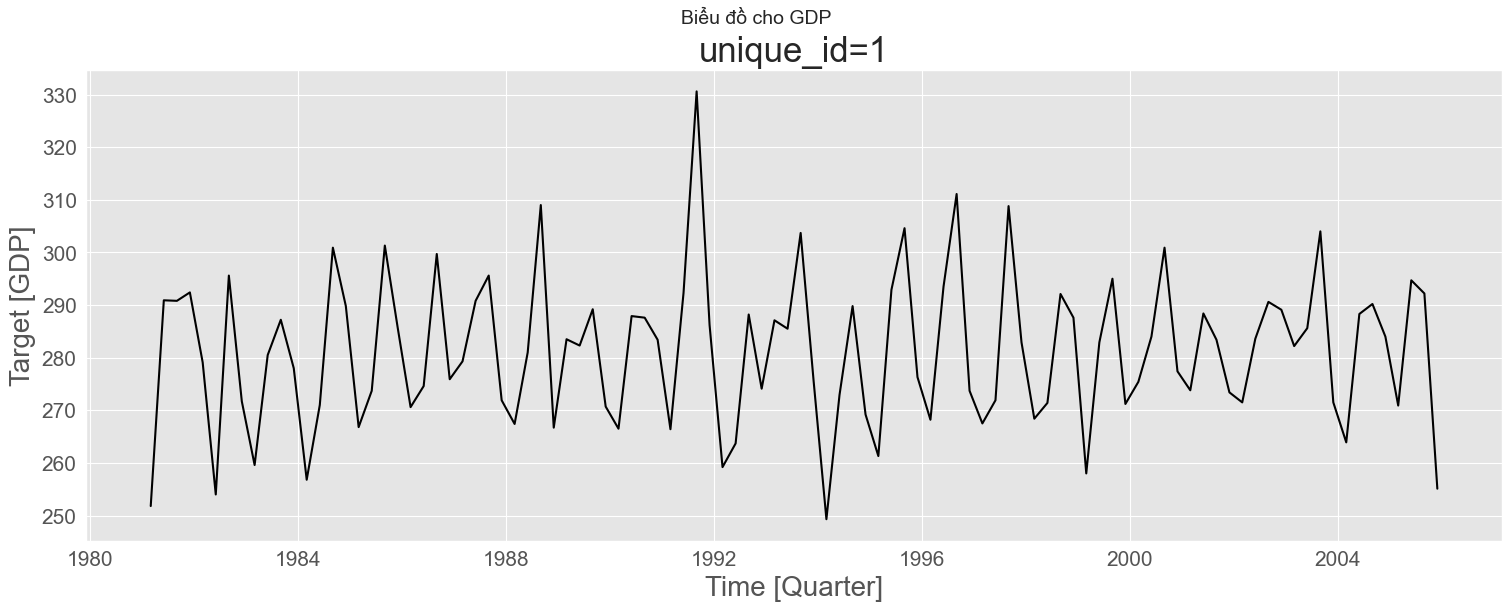

In [7]:
# Answer here
# 1. Đọc dữ liệu
tute1 = pd.read_csv(DATA_DIR / "tute1.csv", parse_dates=["Quarter"])

# 2. Quan trọng: Gán toàn bộ bảng vào 1 ID duy nhất để Nixtla hiểu đây là 1 chuỗi dài
tute1['unique_id'] = 1

cols = ['Sales', 'AdBudget', 'GDP']

for col in cols:
    print(f"--- Đang vẽ cột: {col} ---")
    
    # Gán kết quả hàm plot vào biến fig
    fig = plot_series(
        df=tute1, 
        id_col="unique_id", 
        time_col="Quarter", 
        target_col=col,
        engine="matplotlib"
    )
    
    # Tùy chỉnh tiêu đề cho hình hiện tại
    fig.suptitle(f"Biểu đồ cho {col}", fontsize=14)
    
    # Hiển thị
    display(fig)

### 4. The us_total.csv contains data on the demand for natural gas in the US.

- Download us_total.csv from the book website read in the csv file using pd.read_csv().
- Create a dataframe from us_total with year as the index.
- Plot the annual natural gas consumption by state for the New England area (comprising the states of Maine, Vermont, New Hampshire, Massachusetts, Connecticut and Rhode Island).

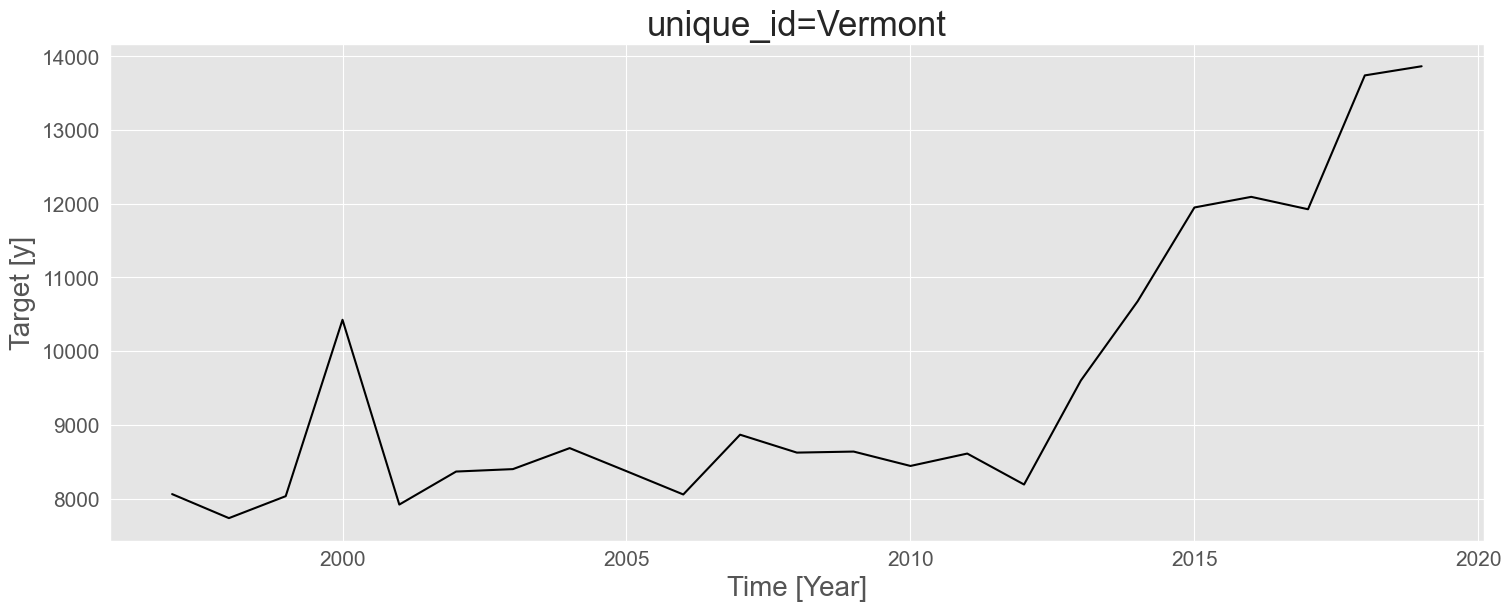

In [8]:
# Answer here
us_total = pd.read_csv(DATA_DIR / "us_total.csv")

# 2. Tạo cột Year (nếu cần thiết để lưu trữ)
us_total['Year'] = us_total['ds'].copy()

# 3. Định nghĩa danh sách các bang
areas = ['Maine', 'Vermont', 'New Hampshire', 'Massachusetts', 'Connecticut', 'Rhode Island']

# 4. Lọc dữ liệu bằng query (sử dụng @ để gọi biến areas)
new_england_area = us_total.query("unique_id in @areas")

# 5. Nếu muốn index là ds để dễ lọc thời gian:
new_england_area_indexed = new_england_area.set_index('ds')


fig = plot_series(
        df=new_england_area_indexed, 
        id_col="unique_id", 
        time_col="Year", 
        target_col='y',
        engine="matplotlib"
    )
# Hiển thị
display(fig)

### 5. 
- Download tourism.xlsx from the book website and read in it using pd.read_excel().
- Create a dataframe using tourism.xlsx.
- Find what combination of Region and Purpose had the maximum number of overnight trips on average.
- Create a new dataframe which combines the Purposes and Regions, and just has total trips by State.

In [9]:
# Answer here
import pandas as pd
df = pd.read_excel(DATA_DIR / 'tourism.xlsx', engine='calamine')
df
# df.to_excel('data/tourism.xlsx', index=False)
region_x_purpose = df.groupby(['Region', 'Purpose'])['Trips'].mean().reset_index()

region_x_purpose_top1 = region_x_purpose.sort_values(by='Trips', ascending=False).head(1)
region_x_purpose_top1

,Region,Purpose,Trips
271,Sydney,Visiting,747.27


In [10]:
total_trips_by_State = df.groupby('State')['Trips'].sum().reset_index()
total_trips_by_State = total_trips_by_State.sort_values('Trips', ascending=False)

total_trips_by_State

,State,Trips
1,New South Wales,557367.430
6,Victoria,390462.911
3,Queensland,386642.912
7,Western Australia,147819.653
4,South Australia,118151.348
5,Tasmania,54137.095
0,ACT,41006.585
2,Northern Territory,28613.683


### 6. The aus_arrivals data set comprises quarterly international arrivals to Australia from Japan, New Zealand, UK and the US.

- Use plot_series() to visualise the data.
- Use seaborn or matplotlib to create seasonal and subseries plots to compare the differences between the arrivals from these four countries and identify any unusual observations

--- Đang hiển thị visual cho: Japan ---


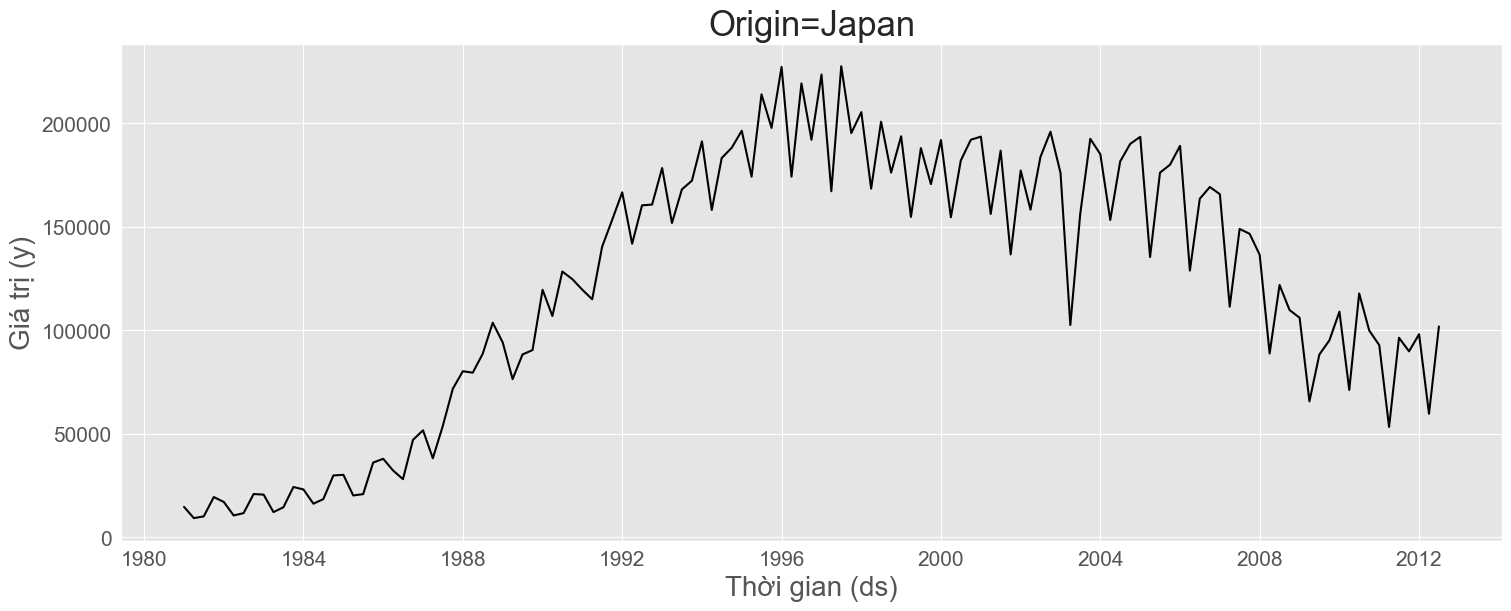

--- Đang hiển thị visual cho: NZ ---


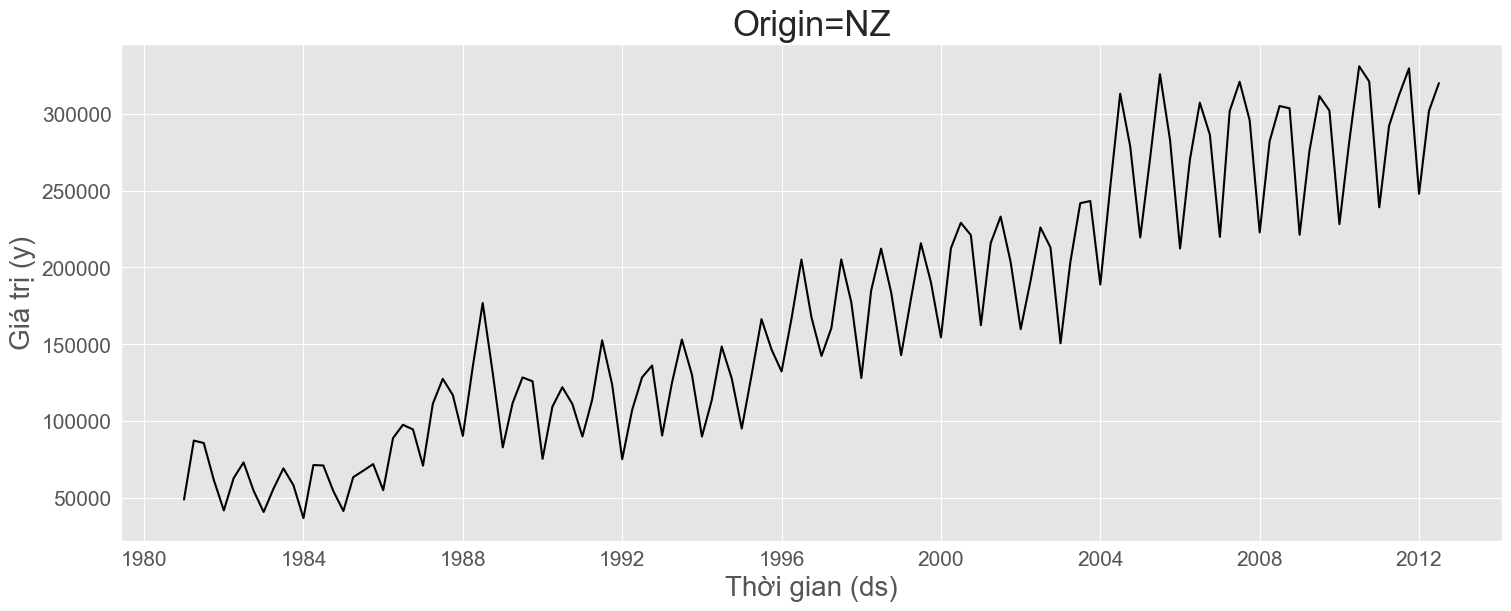

--- Đang hiển thị visual cho: UK ---


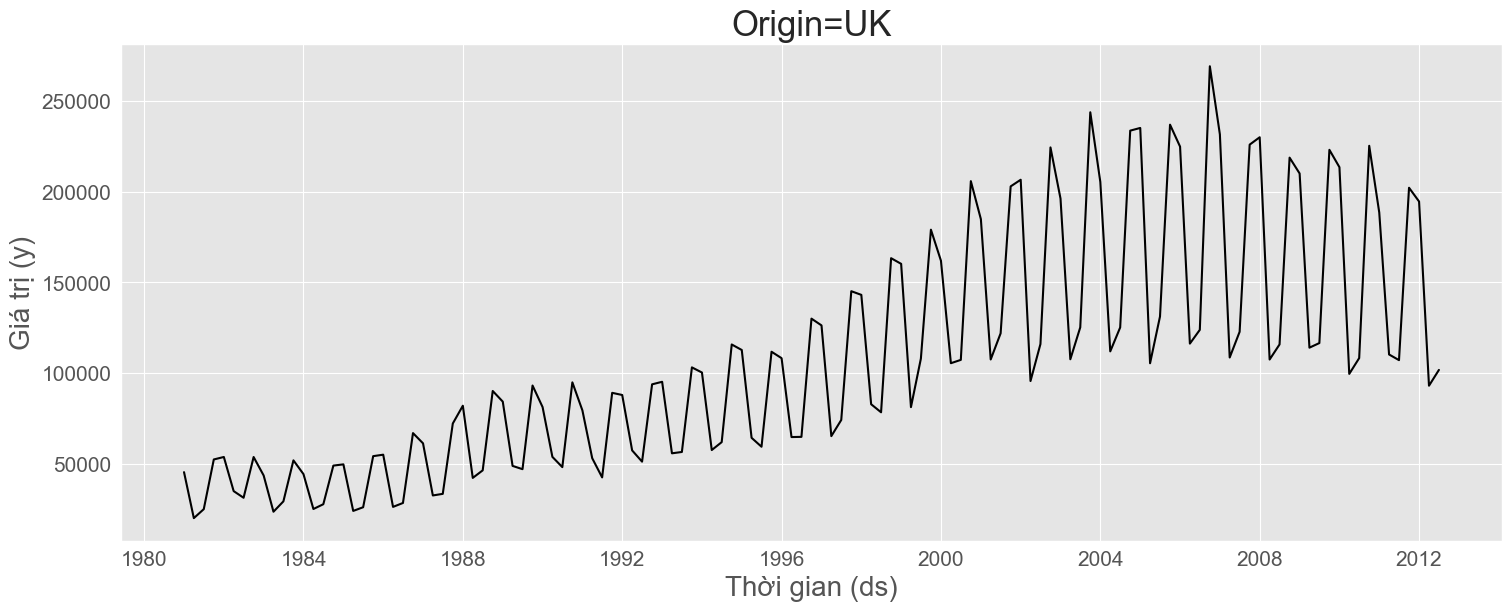

--- Đang hiển thị visual cho: US ---


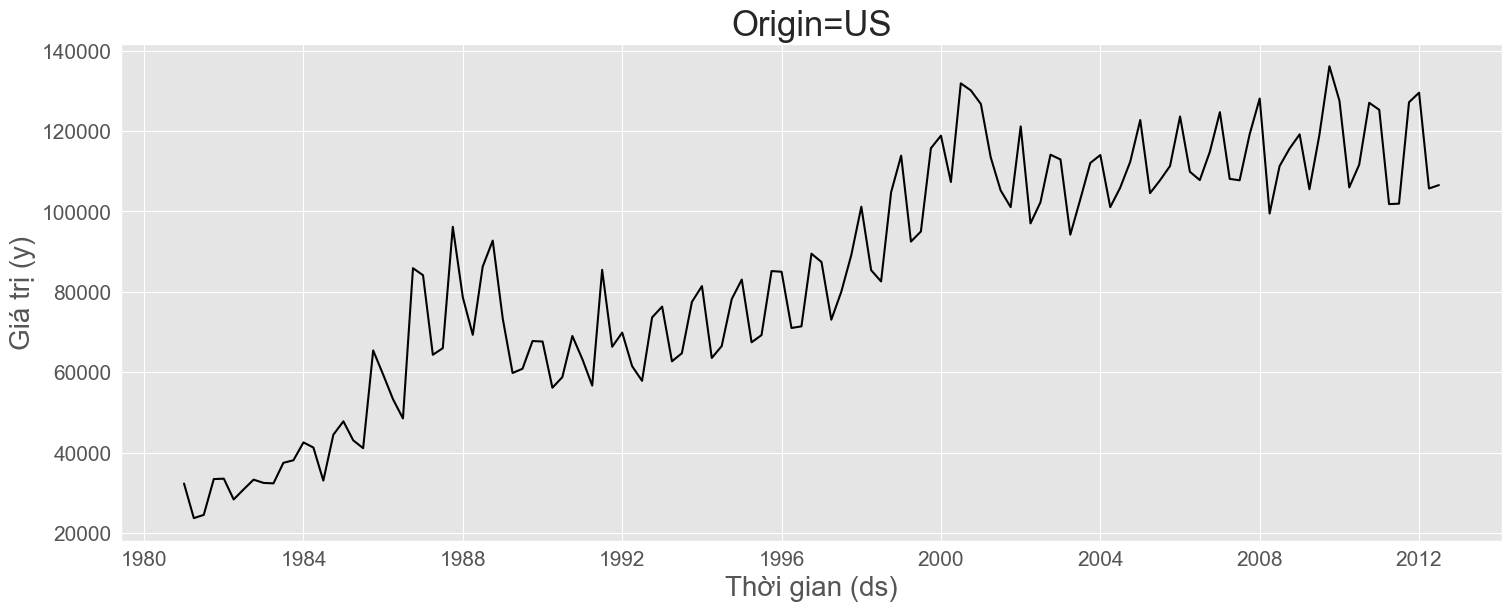

In [11]:
# Answer here
aus_arrivals = pd.read_csv(DATA_DIR / "aus_arrivals.csv", parse_dates = ["Quarter"])
aus_arrivals
arrivals = ['Japan', 'NZ', 'UK', 'US']

for country in arrivals:
    print(f"--- Đang hiển thị visual cho: {country} ---")

    # Bước quan trọng để lọc từng origin
    df_filtered = aus_arrivals.query("Origin == @country")
    
    fig = plot_series(
        df = df_filtered, 
        id_col = "Origin", 
        time_col = "Quarter",
        target_col = "Arrivals",
        engine = "matplotlib"
    )
    for ax in fig.axes:
                ax.set_xlabel("Thời gian (ds)")
                ax.set_ylabel("Giá trị (y)")
    # Hiển thị
    display(fig)


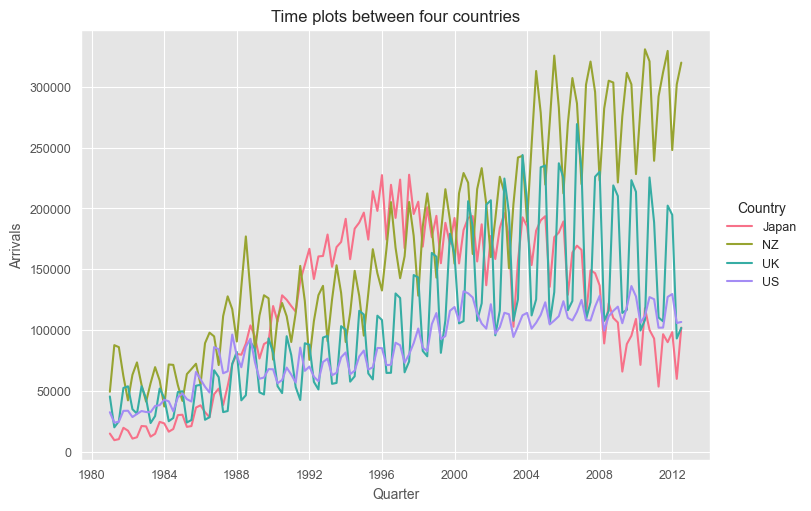

In [12]:
fig, ax = plt.subplots()
palette = sns.color_palette("husl", aus_arrivals["Origin"].nunique())
sns.lineplot(data=aus_arrivals, x="Quarter", y="Arrivals", hue="Origin", palette=palette)
ax.set(
    title="Time plots between four countries",
    ylabel="Arrivals",
    xlabel="Quarter",
)
ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5),
    frameon=False, borderaxespad=0, title="Country")
fig.show()

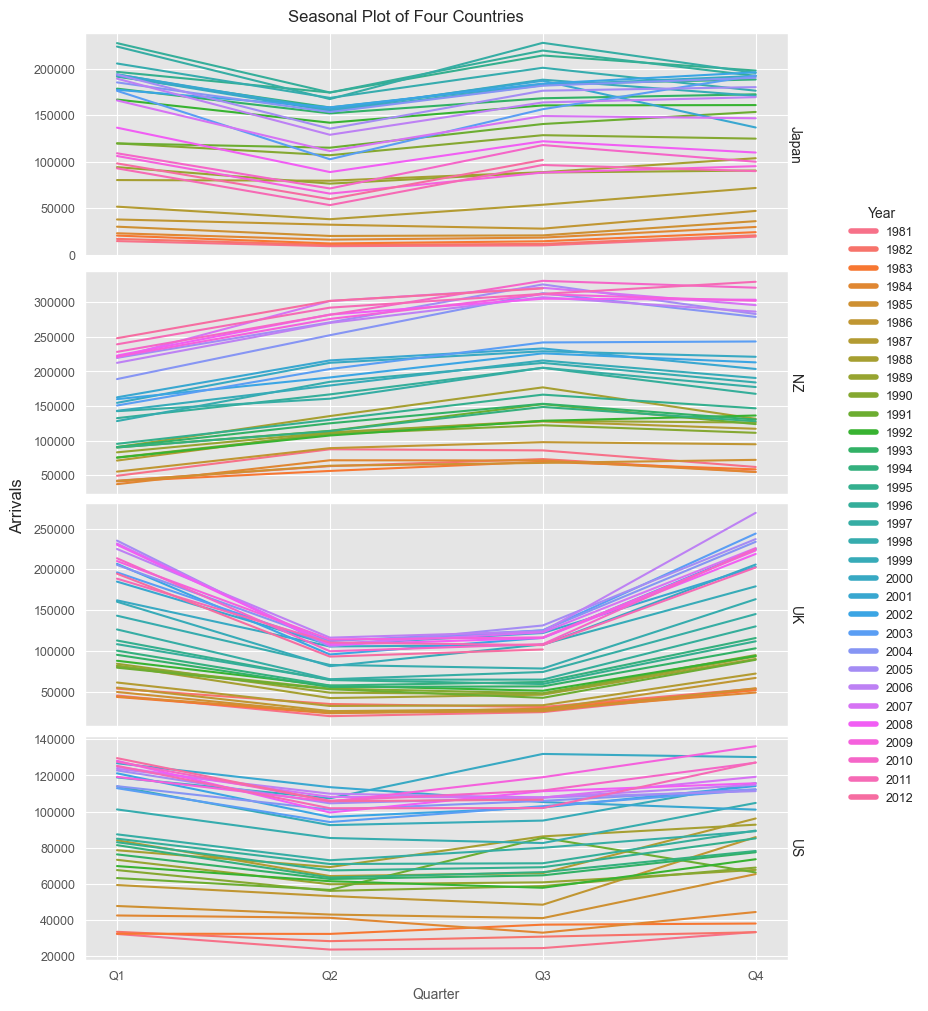

In [13]:
df = aus_arrivals.assign(
    Quarter="Q" + aus_arrivals["Quarter"].dt.quarter.astype("string"),
    Year= aus_arrivals["Quarter"].dt.year,
)
num_states, num_years = df[["Origin", "Year"]].nunique()
palette = sns.color_palette("husl", num_years)
fig, axes = plt.subplots(num_states, sharex=True, figsize=(8, 10))
for ax, (state, state_df) in zip(axes, df.groupby("Origin")):
    sns.lineplot(data=state_df, x="Quarter", y="Arrivals",
        hue="Year", palette=palette, ax=ax)
    ax.get_legend().remove()
    ax.set(ylabel="")
    ax.text(1.02, 0.5, state, va="center", ha="right", rotation=270,
        size="medium", transform=ax.transAxes)
handles, labels = ax.get_legend_handles_labels()
for h in handles:
    h.set(linewidth=4)
fig.legend(handles, labels, title="Year", loc="center left",
    bbox_to_anchor=(1.05, 0.5), frameon=False, borderaxespad=0)
fig.suptitle("Seasonal Plot of Four Countries")
fig.supylabel("Arrivals")
fig.show()

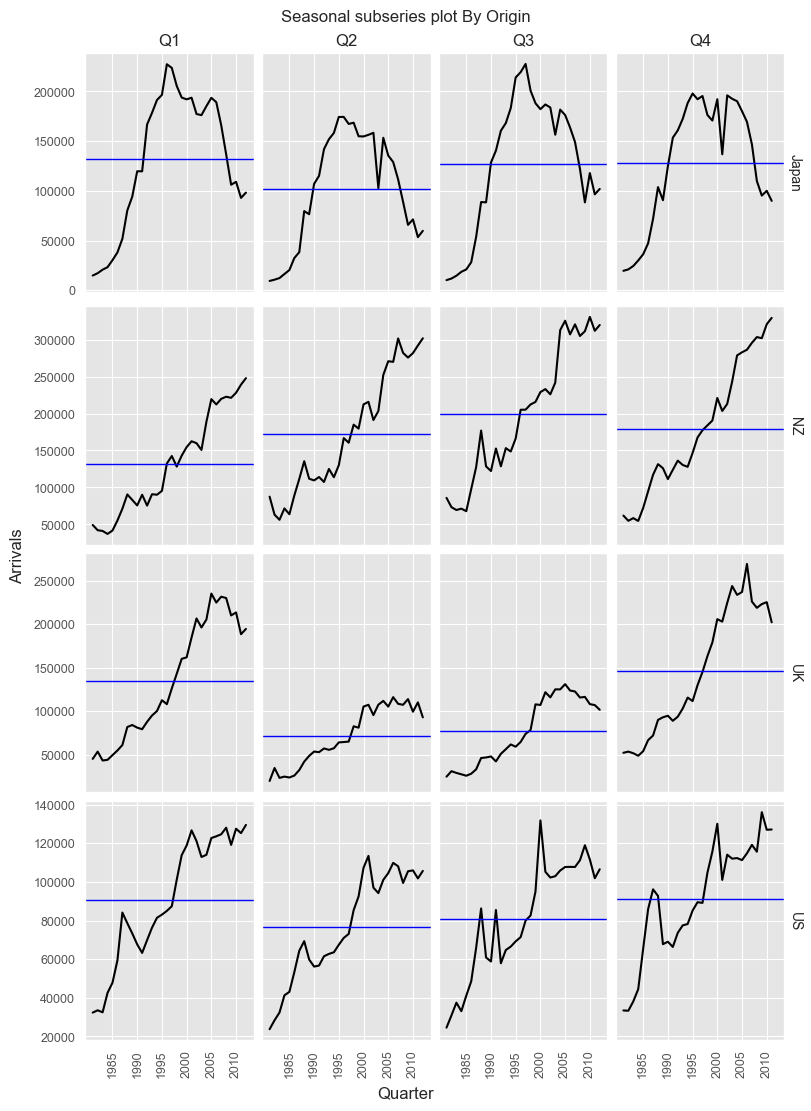

In [14]:
fig, axes = plt.subplots(num_states, 4,
    sharex=True, sharey="row", figsize=(8, 11))
for ax, ((state, quarter), state_df) in zip(
        axes.flat, df.groupby(["Origin", "Quarter"])):
    ax.plot(state_df["Year"], state_df["Arrivals"], color="k")
    ax.axhline(state_df["Arrivals"].mean(), color="b", linewidth=1)
    ax.tick_params(axis="x", rotation=90)
    xticks = state_df["Year"].loc[lambda x: (x % 5) == 0]
    if ax in axes[0]:
        ax.set(title=quarter, xticks=xticks)
    if ax in axes[:, -1]:
        ax.text(1.02, 0.5, state, va="center", ha="left", rotation=270,
            size="medium", transform=ax.transAxes)
fig.suptitle("Seasonal subseries plot By Origin")
fig.supxlabel("Quarter")
fig.supylabel("Arrivals")
fig.show()

##### identify unusual observations
- Japan: có xu hướng giảm so với các nước khác. Đạt đỉnh 1997-1998 và sau đó lao dốc. Điểm bất thường là cuối năm 2003 và năm 2011 có cú rơi rất sâu do một sự kiện nào đó.
- New Zealand: tăng trưởng liên tục, có bước nhảy vọt ở năm 2004 khi vượt qua Japan và UK về số lượng arrivals để trở thành nguồn khách lớn nhất và duy trì vị trí các năm sau đó.
- UK: có tính mùa vụ rất mạnh khi the variation thay đổi rất rõ ở cuối năm so với đầu năm thể hiện nhu cầu rất cao vào các dịp lễ như Noel or New year. Đạt đỉnh ở giai đoạn 2005 - 2007 do các sự kiện thể thao lớn (thế vận hội mùa đông I guess).
- US: Giai đoạn 2001-2002: Bạn sẽ thấy một đoạn trũng xuống ở đường màu tím. Đây là tác động toàn cầu của sự kiện 11/9, khiến ngành hàng không thế giới tê liệt, đặc biệt là khách từ Mỹ. Giai đoạn 2008-2009: Một cú sụt giảm nhẹ khác tương ứng với Khủng hoảng tài chính toàn cầu (GFC).

### 7. Monthly Australian retail data is provided in aus_retail. Select one of the time series as follows (but choose your own seed value):
- Explore your chosen retail time series using the following functions: plot_series(), seasonal_decompose(), lag_plot(), plot_acf()
- Can you spot any seasonality, cyclicity and trend? What do you learn about the series? 

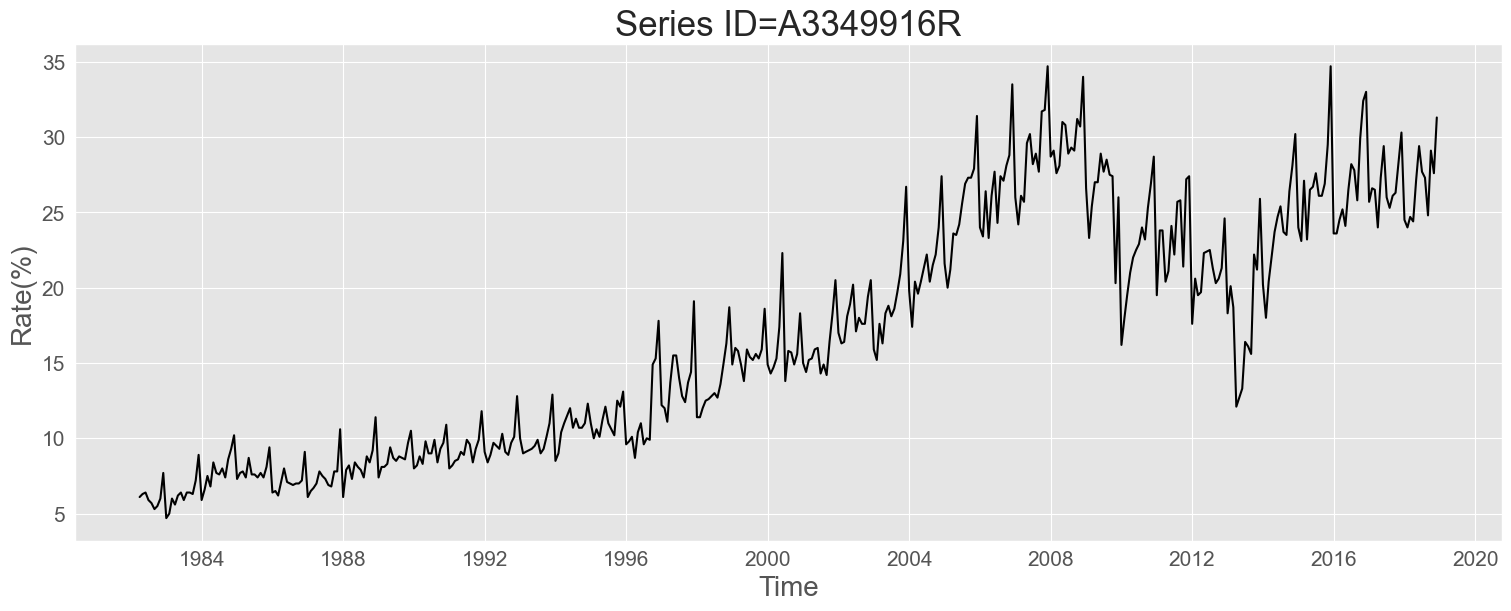

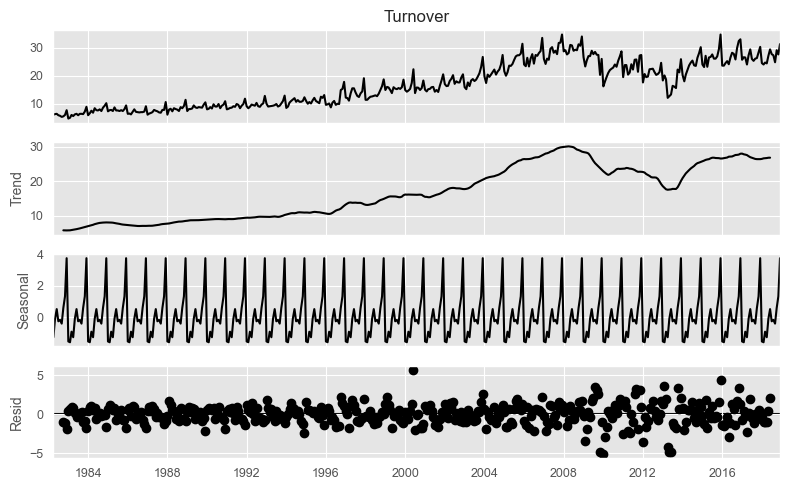

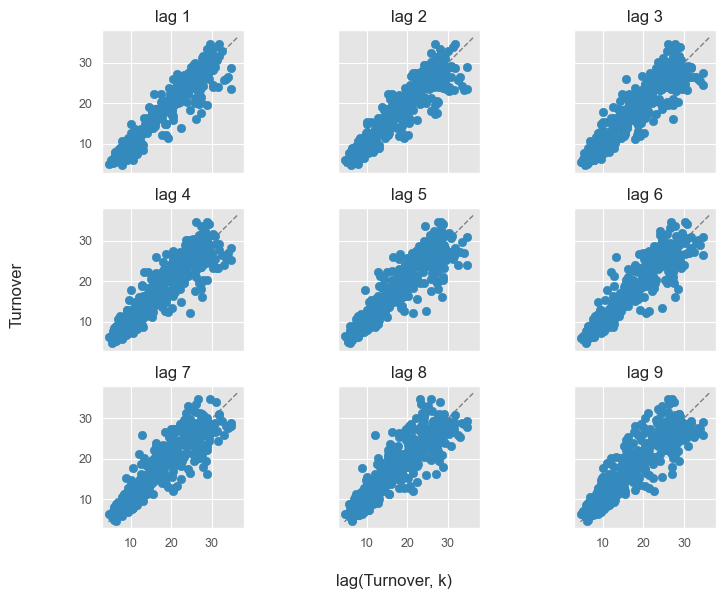

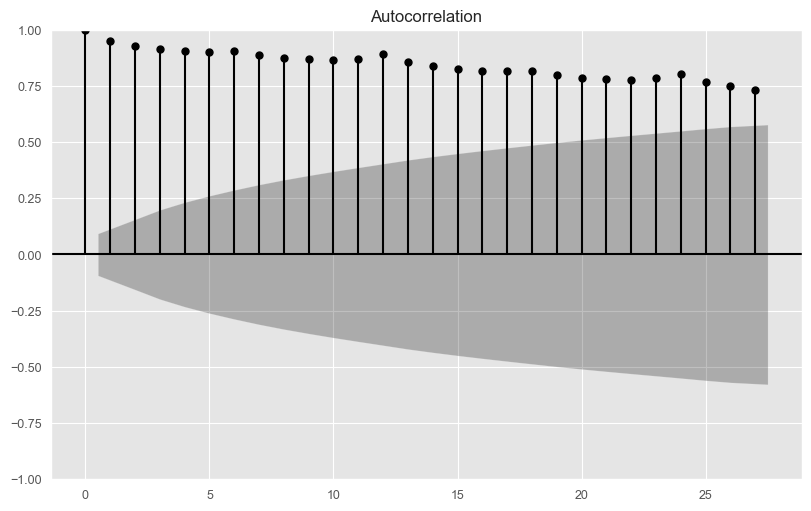

In [15]:
# Answer here
aus_retail = pd.read_csv(DATA_DIR / "aus_retail.csv", parse_dates = ['Month'])
aus_retail

random = np.random.RandomState(42)
random_series_id = random.choice(aus_retail["Series ID"].unique())
myseries = aus_retail.loc[aus_retail["Series ID"] == random_series_id]
myseries

# Time Series Plot
fig1 = plot_series(myseries, time_col = 'Month', id_col = 'Series ID', target_col = 'Turnover')
for ax in fig1.axes:
    ax.set_ylabel("Rate(%)")
    ax.set_xlabel("Time")
display(fig1)

# Seasonal Decomposition Plot
x = myseries.copy()
# Ensure the Month column is parsed as datetime
x['Month'] = pd.to_datetime(x['Month'])
x_series = x.set_index('Month')['Turnover']
fig2 = seasonal_decompose(x=x_series, model="additive", period=12)
fig2.plot()
plt.show()

# Lag Plots
lims = .95 * myseries["Turnover"].min(), 1.05 * myseries["Turnover"].max()
fig3, axes = plt.subplots(3, 3, figsize=(8, 6), sharex=True, sharey=True)
for i, ax in enumerate(axes.flat):
    lag = i + 1
    # Pass 'ax=ax' to force the plot into the correct subplot
    pd.plotting.lag_plot(series=myseries['Turnover'], lag=lag, ax=ax)
    # Add a diagonal dashed line for reference
    ax.plot(lims, lims, color=".5", ls="--", lw=1, zorder=-1)
    ax.set(title=f"lag {lag}", xlabel="", ylabel="", aspect="equal")
fig3.supxlabel("lag(Turnover, k)")
fig3.supylabel("Turnover")
plt.tight_layout()
plt.show()

# Autocorrelation Plots
fig4 = plot_acf(x = myseries['Turnover'])
plt.show()

##### Nhận xét:
- In time plot, we can see the gradually growth of the turnover through years. The Turnover values get the peak at the end of 2007 and the beginning of 2008. However, this product got the deeply dip, the turnover values was constantly decreasing from 2009 to 2014 due to some reasons, idk. After this bad period, this product are getting into the track.
- In seasonal decomposition plot, we can apperently see that the plot has a strong reasonality.
- In Autocorrelation plot, The autocorrelation bars will stay tall and positive for many lags, only decreasing very gradually. This indicates **a strong long-term trend** in your data (retail turnover has steadily increased over the decades). Because today's value is higher than yesterday's, and yesterday's is higher than the day before, observations close together in time are strongly correlated.

### 8. Use the following graphics functions: plot_series(), seasonal_decompose(), lag_plot(), plot_acf() and explore features from the following time series: “Total Private” Employed from us_employment, Bricks from aus_production, Hare from pelt, “H02” Cost from PBS, and Barrels from us_gasoline. 
- Can you spot any seasonality, cyclicity and trend?
- What do you learn about the series?
- What can you say about the seasonal patterns?
- Can you identify any unusual years?

---Time series plot---
--- Đang hiển thị visual cho: us_employment ---


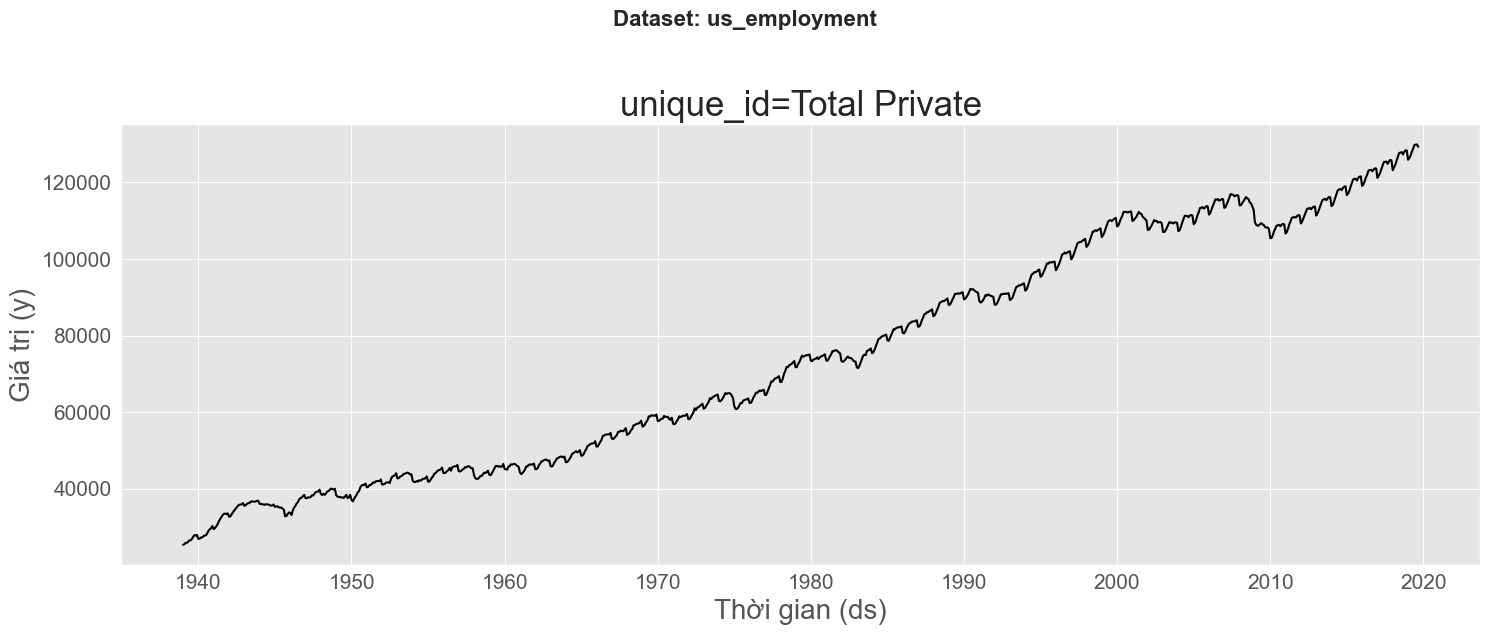

--- Đang hiển thị visual cho: aus_production ---


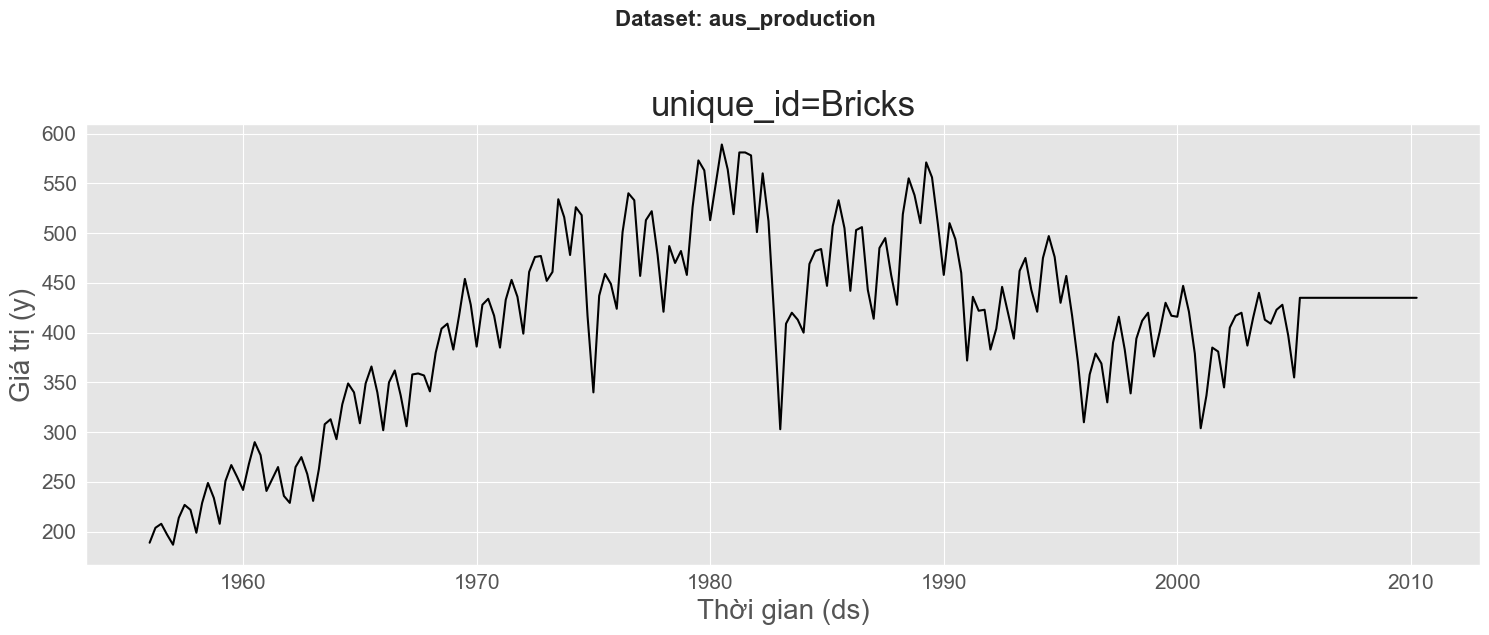

--- Đang hiển thị visual cho: pelt ---


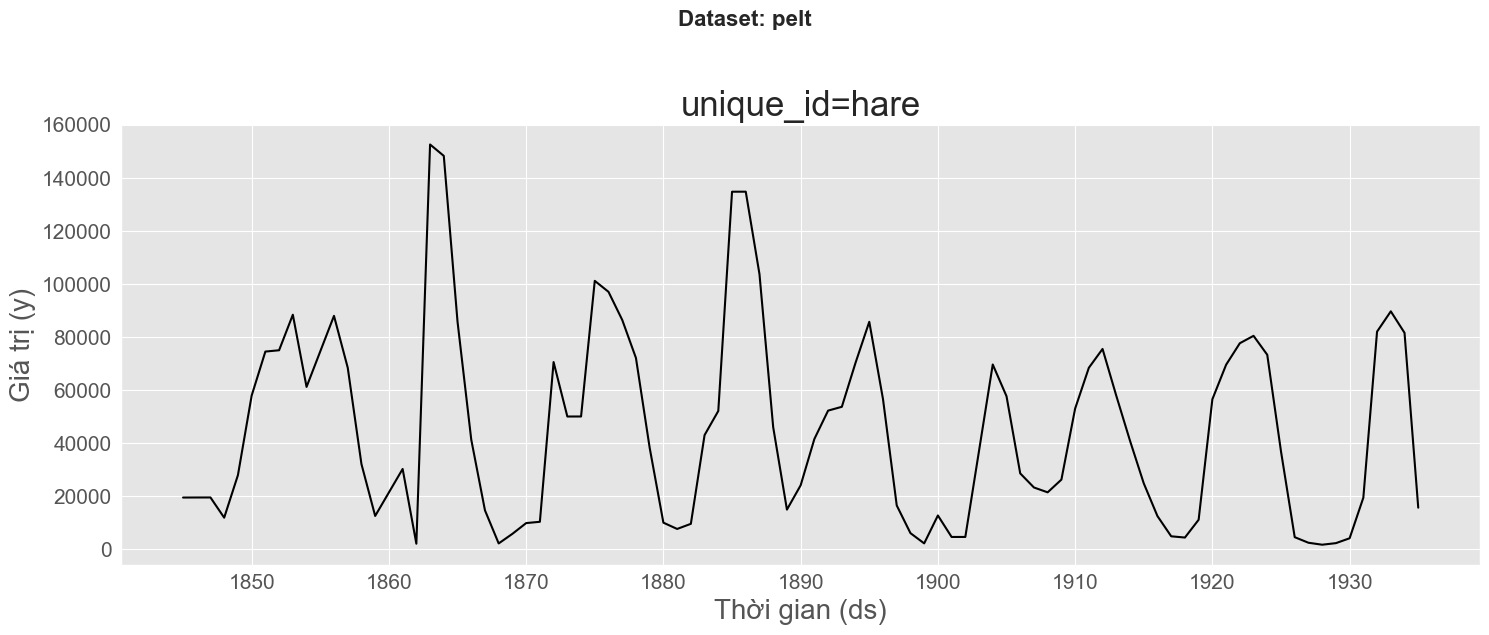

--- Đang hiển thị visual cho: pbs ---


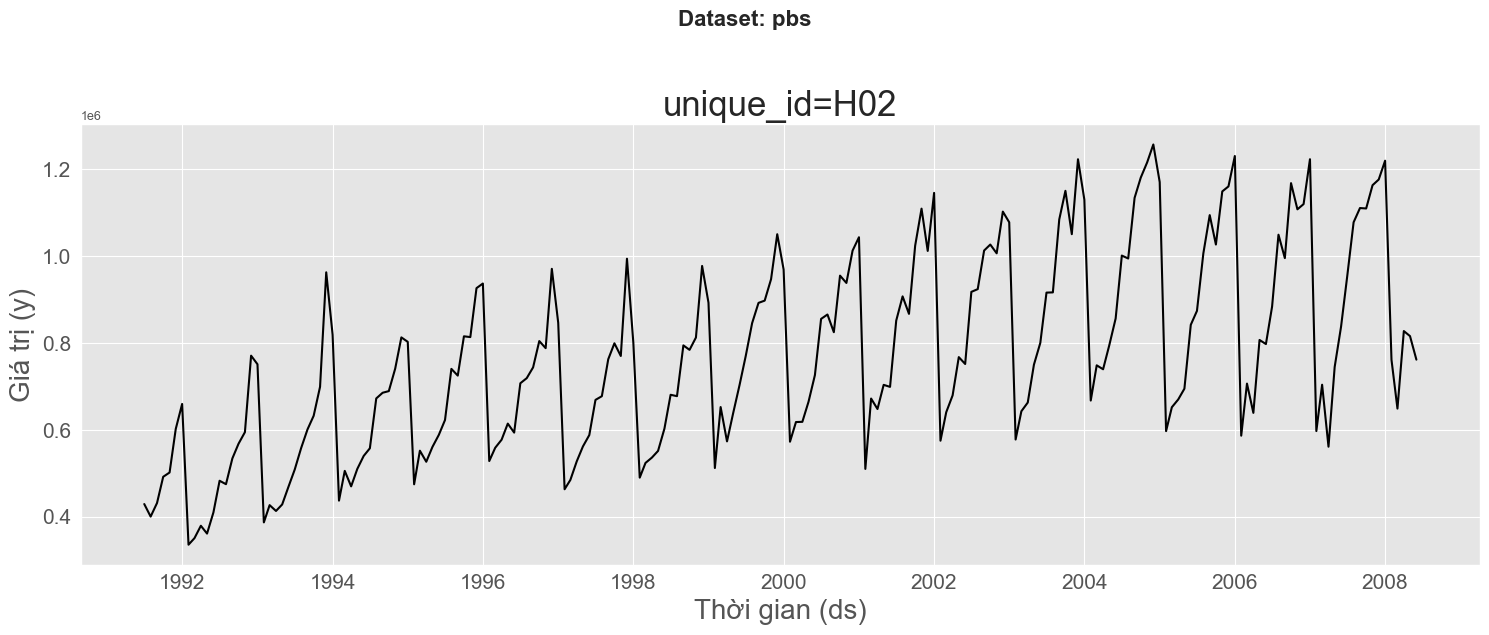

--- Đang hiển thị visual cho: us_gasoline ---


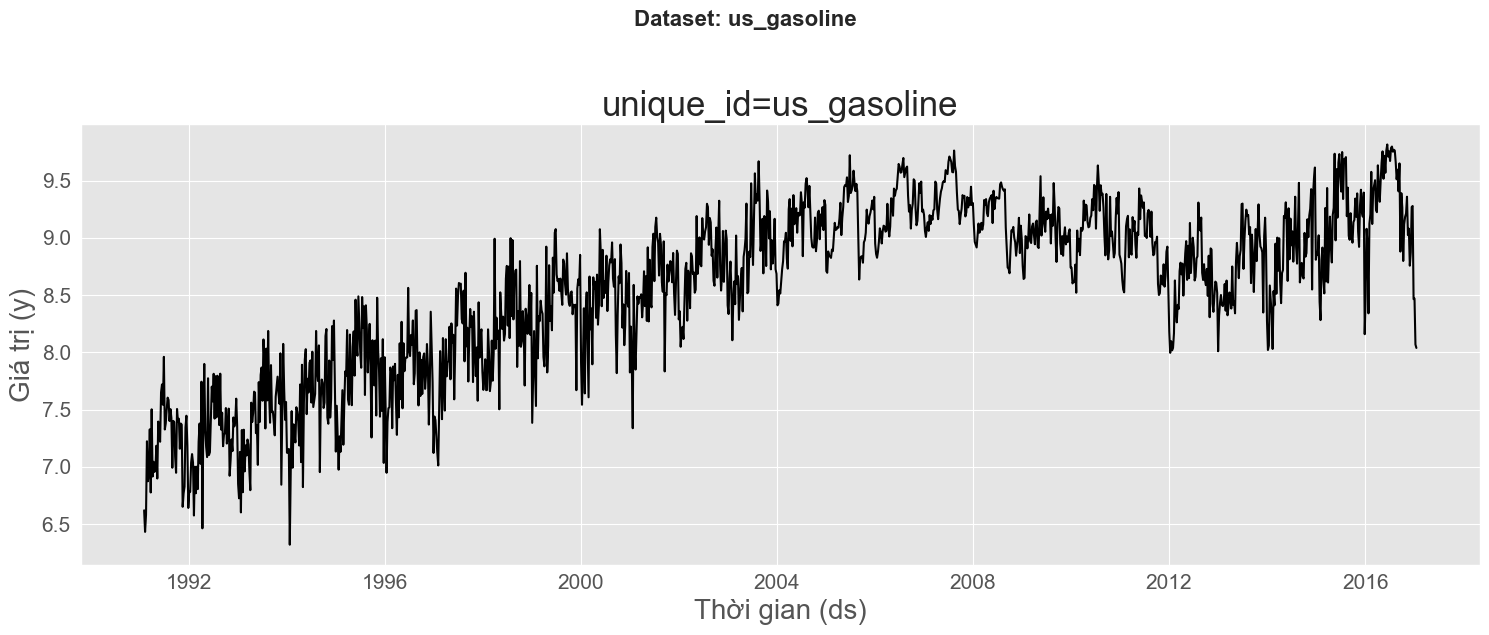

---Seasonal Decomposition plot---
--- Đang hiển thị visual cho: us_employment ---


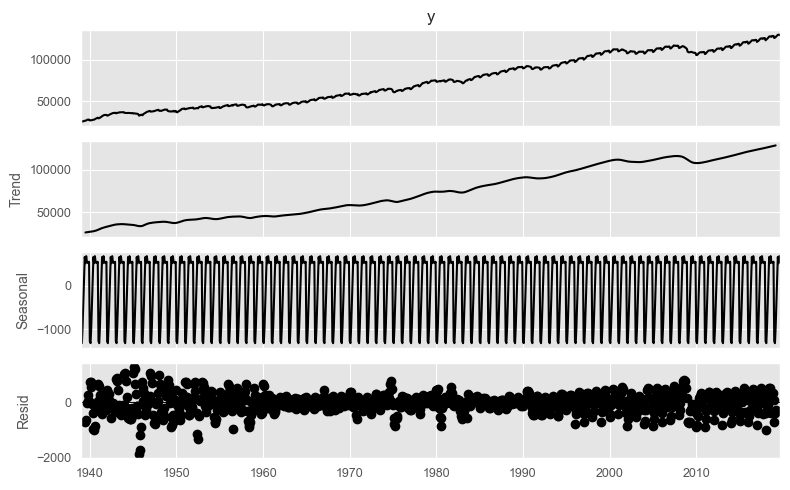

--- Đang hiển thị visual cho: aus_production ---


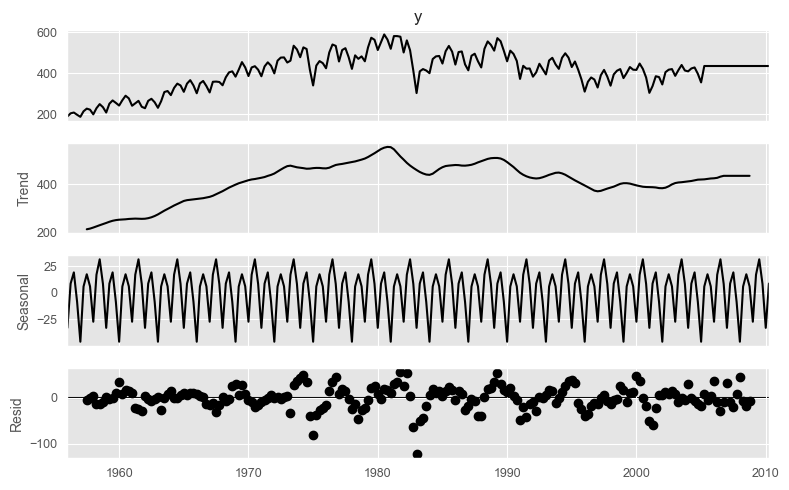

--- Đang hiển thị visual cho: pelt ---


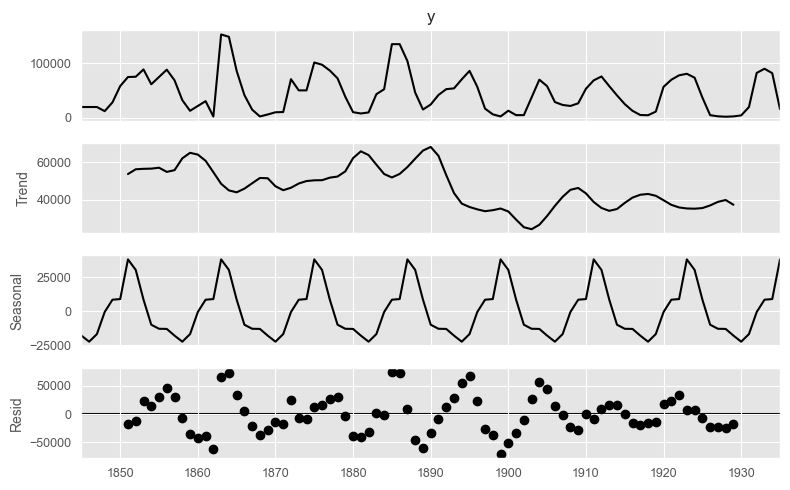

--- Đang hiển thị visual cho: pbs ---


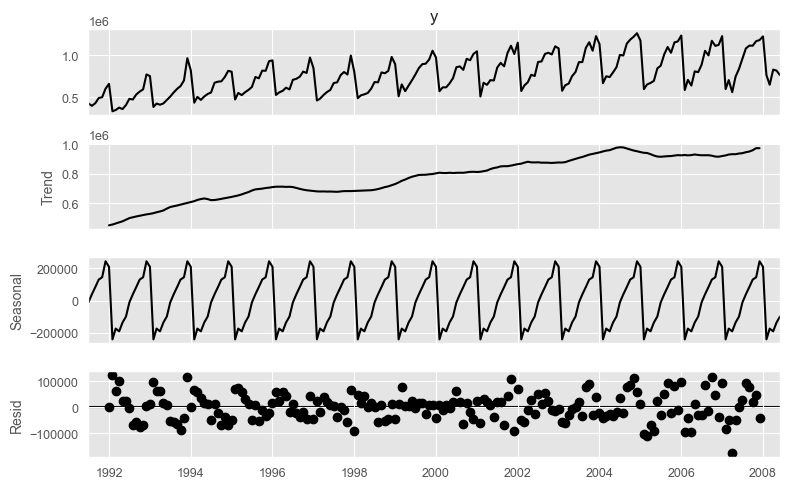

--- Đang hiển thị visual cho: us_gasoline ---


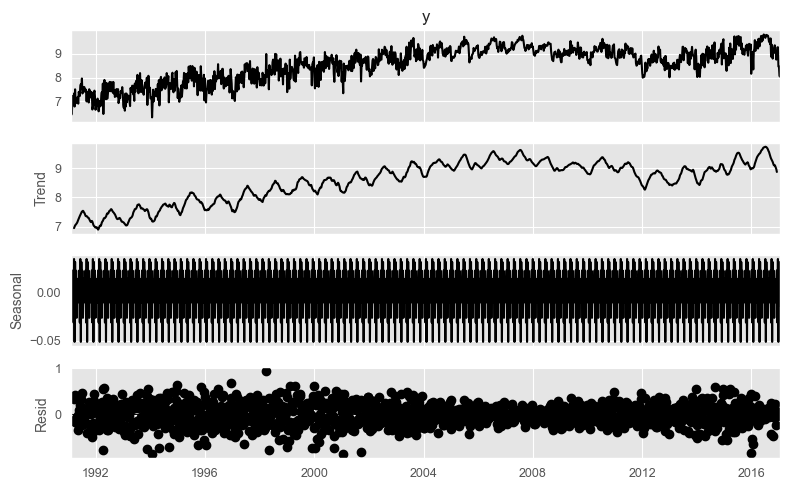

---Autocorrelaion plot---
--- Đang hiển thị visual cho: us_employment ---


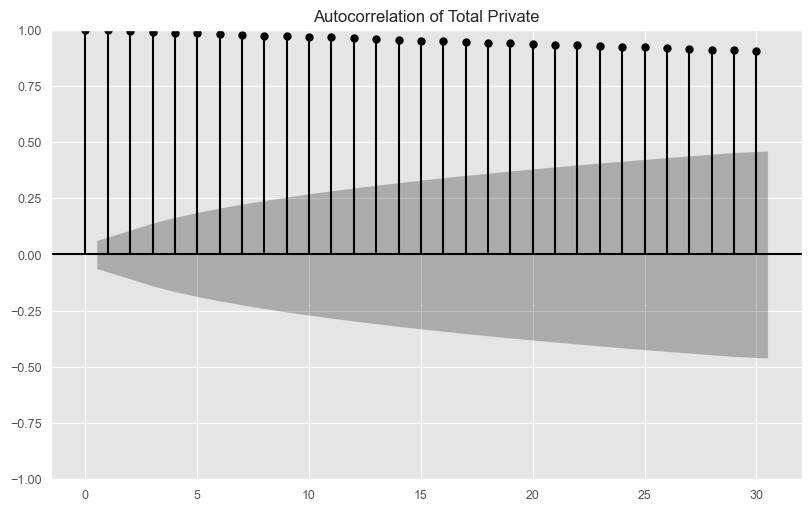

--- Đang hiển thị visual cho: aus_production ---


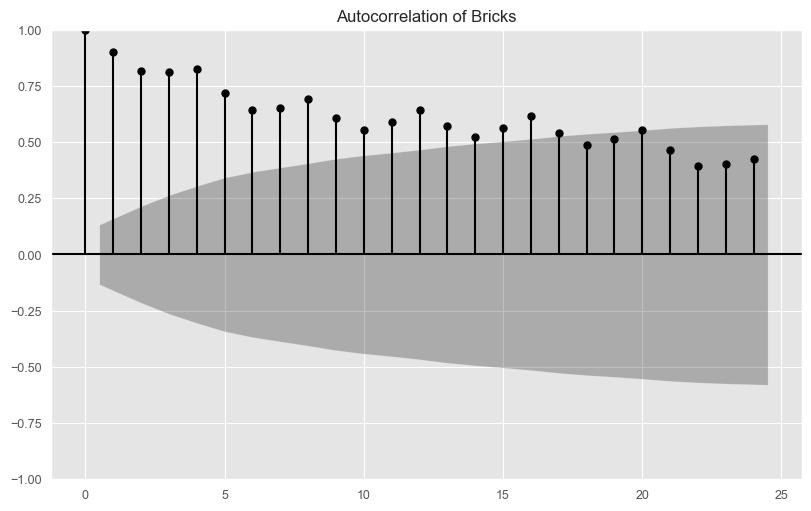

--- Đang hiển thị visual cho: pelt ---


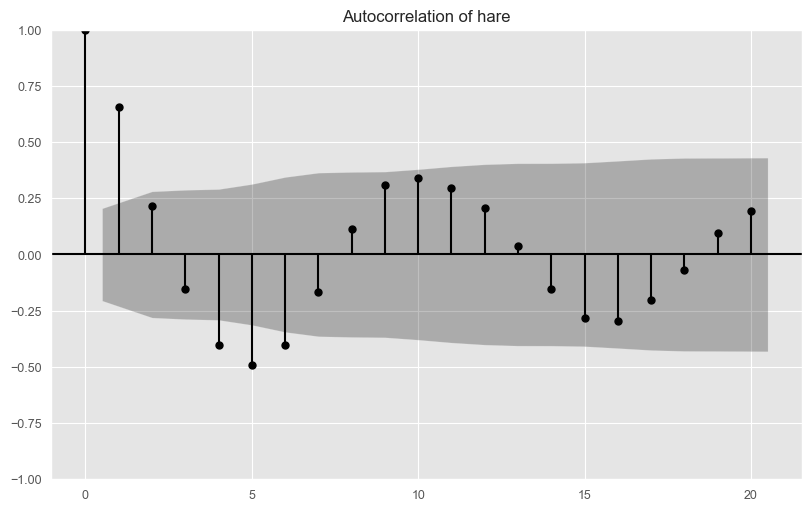

--- Đang hiển thị visual cho: pbs ---


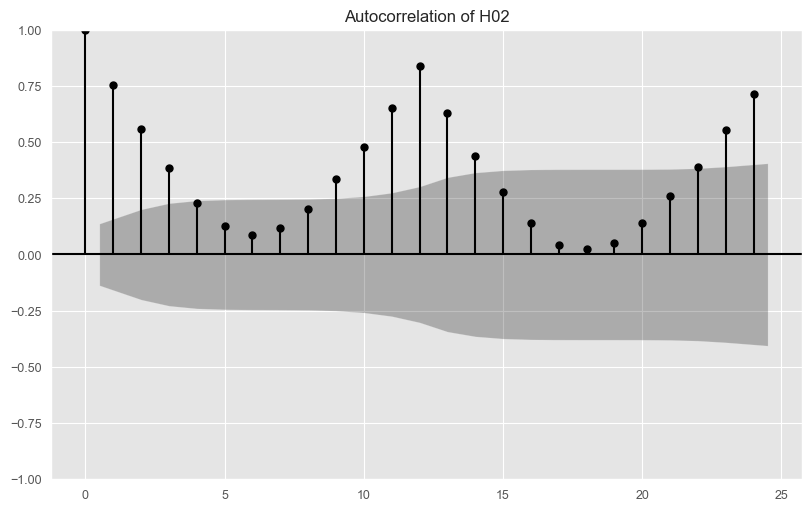

--- Đang hiển thị visual cho: us_gasoline ---


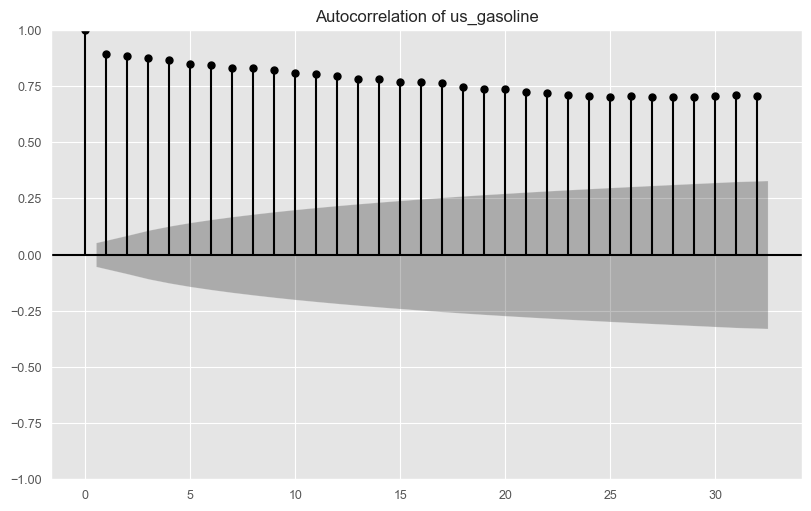

In [16]:
# Answer here

# loading dataset
us_employment = (
    pd.read_csv(DATA_DIR / "us_employment.csv", parse_dates = ['ds'])
    .loc[lambda x: (x['unique_id'] == 'Total Private')]
    .reset_index()
    .drop('index', axis = 1, inplace = False)
)
aus_production = (
    pd.read_csv(DATA_DIR / "aus_production.csv", parse_dates=['ds'])
    .assign(unique_id="Bricks")
    .rename(columns={"Bricks": "y"})
    .sort_values('ds')
    # 2. Apply the imputation chain to the target column 'y'
    .assign(y=lambda x: x['y'].interpolate().bfill().ffill())
    [['unique_id', 'ds', 'y']]
)
pelt = (
    pd.read_csv(DATA_DIR / "pelt.csv", parse_dates = ['ds'])
    .loc[lambda x: (x['unique_id'] == "hare")]
)
pbs = (
    pd.read_csv(DATA_DIR / "pbs.csv", parse_dates = ['Month'])
    .drop(columns=["Unnamed: 0"], errors='ignore') 
    .loc[lambda x: x['ATC2'] == 'H02']
    .rename(columns = {"Month": "ds", "ATC2": "unique_id", "Cost": "y"})
    # PBS có nhiều dòng cho cùng 1 tháng (ví dụ: chia theo đối tượng khách hàng)
    # Ta cần sum() lại để mỗi tháng chỉ có 1 con số y duy nhất
    .groupby(['unique_id', 'ds'])['y'].sum().reset_index()
    .sort_values('ds')
    [['ds', 'unique_id', 'y']]
    .reset_index(drop=True)
)
us_gasoline = (
    pd.read_csv(DATA_DIR / "us_gasoline.csv", parse_dates = ['ds'])
)
# display(us_employment)
# display(aus_production)
# display(pelt)
# display(pbs)
# display(us_gasoline)

# plotting 
print("=======================================================")
print("---Time series plot---")
print("=======================================================")
datasets = {"us_employment": us_employment, 
            "aus_production": aus_production,
            "pelt": pelt,
            "pbs": pbs,
            "us_gasoline": us_gasoline}
# Chạy hàm đã xây dựng sẵn ở câu 1
plot_each_series(datasets)

print("=======================================================")
print("---Seasonal Decomposition plot---")
print("=======================================================")
def plot_each_seasonal_decompose(x):
    for name, df in x.items():
        print(f"--- Đang hiển thị visual cho: {name} ---")
        
        # Convert 'ds' to datetime
        df['ds'] = pd.to_datetime(df['ds'])
        
        # FIX: Set the 'ds' column as the index, and extract the 'y' column as a Series
        x_series = df.set_index('ds')['y']
        # Run decomposition
        a = seasonal_decompose(x=x_series, model="additive", period=12)
        a.plot();
        plt.show()

        # Thêm tiêu đề tổng cho cả cụm biểu đồ
        fig.suptitle(f"Dataset: {name}", fontsize=16, fontweight='bold', y=1.05)
        
        # Duyệt qua từng biểu đồ con (axes) để thêm label
        for ax in fig.axes:
            ax.set_xlabel("Thời gian (ds)")
            ax.set_ylabel("Giá trị (y)")
        # Tự động căn chỉnh để không bị dính chữ
        fig.tight_layout()
        fig.show() 

# Chạy hàm
plot_each_seasonal_decompose(datasets)

print("=======================================================")
print("---Autocorrelaion plot---")
print("=======================================================")
def plot_each_acf(x):
    for name, df in x.items():
        print(f"--- Đang hiển thị visual cho: {name} ---")
        plot_acf(x = df['y'], title = f"Autocorrelation of {df['unique_id'][0]}")
        plt.show()

# Chạy hàm
plot_each_acf(datasets)


Nhận xét:
- Can you spot any seasonality, cyclicity and trend?
Yes, of course. I used seasonal_decompose function in statsmodel to decay and visualize.
- What do you learn about the series?
I studied how to preprocess the input data and transform into the consistent format. Then visualize them with building the function. 
- What can you say about the seasonal patterns?
Can you identify any unusual years?

### 9. The following time plots and ACF plots correspond to four different time series. Your task is to match each time plot in the first row with one of the ACF plots in the second row.

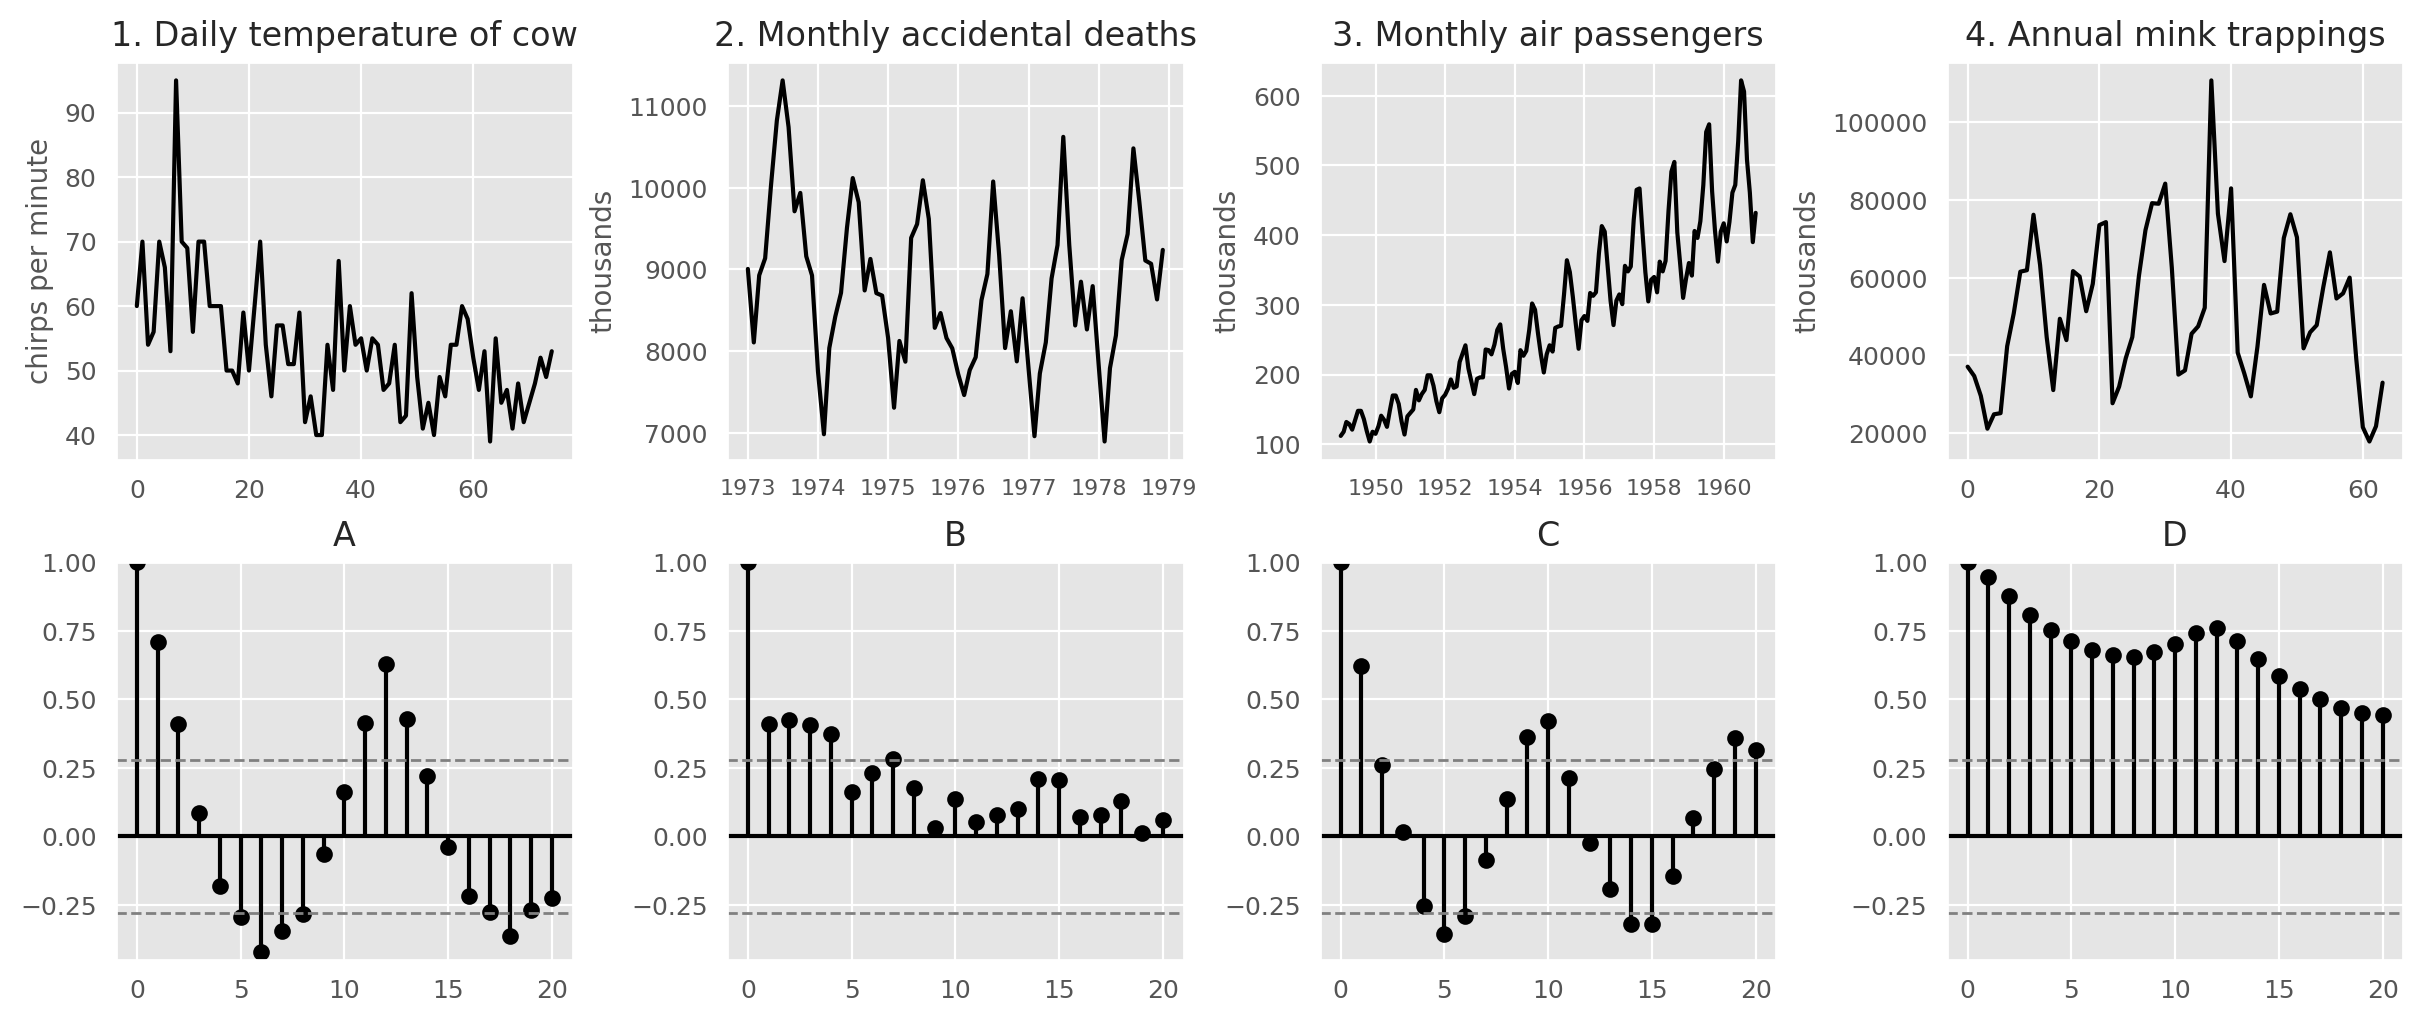


Answer here
- 1. with B
- 2. with A
- 3. with D
- 4. with C




3 Classic Patterns
- Pattern 1: Trend (Slow Decay). If the first few lags are very tall and slowly step down like a staircase, your data has a trend (it is moving generally up or down over time).

- Pattern 2: Seasonality (Scalloped/Waves). If the lines go up and down in a wave pattern, and have distinct "spikes" that poke out of the confidence interval at regular intervals (e.g., at Lag 12 and Lag 24 for monthly data), your data has seasonality.

- Pattern 3: White Noise (Nothing). If all the lines immediately drop into the shaded confidence interval and stay there, your data is completely random. There is no pattern to forecast.

###### Explaination

1 matches B (Noisy / Stationary): Plot 1 (Daily temperature/chirps) is quite noisy and fluctuates around a relatively stable average without a strong long-term cycle or trend. ACF B perfectly reflects this: it shows some short-term correlation (the first few lags are positive) that quickly dies out into the noise (the grey dashed lines).

2 matches A (Pure Seasonality): Plot 2 (Monthly accidental deaths) has very strong, consistent seasonal peaks and troughs every year, but no overall long-term upward or downward trend. ACF A shows this pure seasonality perfectly with a wave that drops to a trough around 6 months and peaks precisely at Lag 12 (one year later).

3 matches D (Strong Trend + Seasonality): Plot 3 (Monthly air passengers) is dominated by a massive upward trend. As you now know, a strong trend causes the ACF to decay very slowly, staying highly positive for a long time. ACF D shows exactly this slow decay. If you look closely at D, you can even see tiny "scallops" (ripples) on top of the slow decay, which represents the seasonality of the airline passengers mixed in with the trend.

4 matches C (Cyclical): Plot 4 (Annual mink trappings) shows a multi-year ecological boom-and-bust cycle. Because this is annual data, there is no "Lag 12" monthly seasonality. Instead, ACF C shows a classic cyclical wave that bottoms out at Lag 5 and peaks at Lag 10, indicating a 10-year population cycle

### 10.The aus_livestock data contains the monthly total number of pigs slaughtered in Victoria, Australia, from Jul 1972 to Dec 2018. Use .loc[] to extract pig slaughters in Victoria between 1990 and 1995. Use plot_series() and plot_acf() for this data. How do they differ from white noise? If a longer period of data is used, what difference does it make to the ACF?

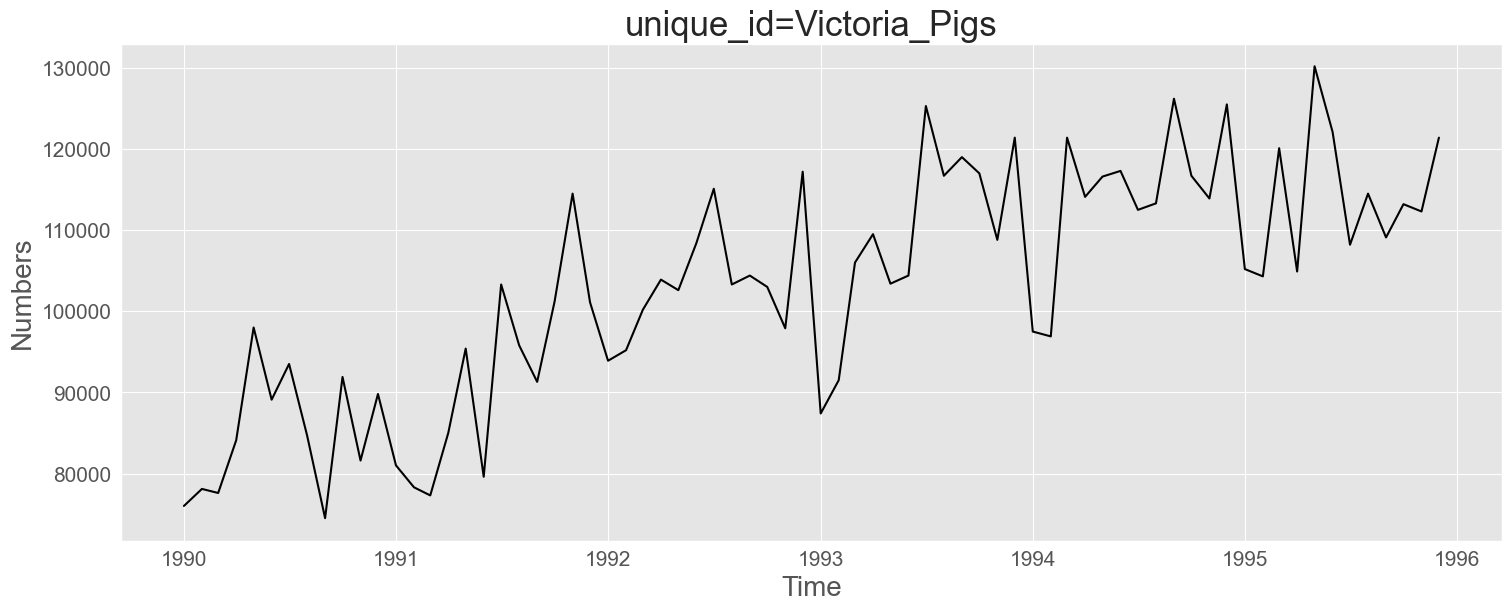

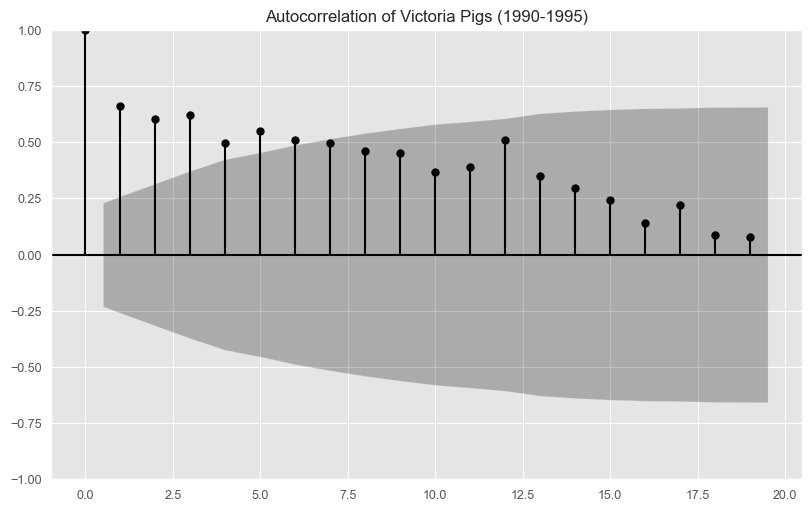

In [20]:
# Answer here

pigs = pd.read_csv(DATA_DIR / "aus_livestock.csv", parse_dates=['ds'])

pigs_90_95 = pigs.loc[
    (pigs['unique_id'] == 'Victoria_Pigs') &
    (pigs['ds'] >= '1990-01-01') &                 
    (pigs['ds'] <= '1995-12-31')                   
].sort_values(by='ds')


fig = plot_series(pigs_90_95, time_col='ds', engine='matplotlib') 
for ax in fig.axes:
    ax.set_xlabel('Time')
    ax.set_ylabel('Numbers')
display(fig)


fig2 = plot_acf(x=pigs_90_95['y'], title="Autocorrelation of Victoria Pigs (1990-1995)")
plt.show()

1. Chúng khác với White Noise (Nhiễu trắng) như thế nào?
Trên biểu đồ Time Series: Nhiễu trắng sẽ nhảy múa hoàn toàn ngẫu nhiên quanh một đường ngang trung bình, không có hướng đi rõ rệt. Tuy nhiên, ở dữ liệu Victoria Pigs này, bạn thấy rõ một xu hướng tăng (Upward Trend) rất mạnh. Số lượng heo giết mổ tăng dần từ mức ~80.000 (năm 1990) lên hơn 120.000 (năm 1995).

Trên biểu đồ ACF: Nếu là nhiễu trắng, gần như tất cả các vạch đen (lags) sẽ rớt ngay vào bên trong dải màu xám (vùng không có ý nghĩa thống kê) ngay từ Lag 1. Nhưng ở đây, bạn thấy các vạch giảm dần một cách từ từ (slow decay) và liên tục vượt ra ngoài vùng xám. Đây là "chữ ký" đặc trưng của một chuỗi dữ liệu có chứa xu hướng (Trend).

2. Sẽ có sự khác biệt gì ở ACF nếu dùng chuỗi dữ liệu dài hơn?
Nếu bạn kéo dài dữ liệu ra (ví dụ lấy từ 1980 đến 2010 thay vì chỉ 1990-1995), biểu đồ ACF sẽ có hai thay đổi cực kỳ quan trọng:

Vùng xám (Confidence Interval) sẽ hẹp lại: Vùng xám này được tính toán dựa trên cỡ mẫu (số lượng tháng). Dữ liệu càng nhiều, dải xám này càng bị ép xẹp xuống. Điều này khiến cho việc kiểm định các mối tương quan trở nên khắt khe và nhạy bén hơn.

Phơi bày tính tổng quát của mô hình: Việc mở rộng khung thời gian phân tích là bước đi cốt lõi để chứng minh tính tổng quát (generalizability) và độ bền vững (robustness) của các xu hướng. Xu hướng tăng liên tục trong 5 năm này có thể chỉ là một biến động kinh tế ngắn hạn. Khi nhìn trên tập dữ liệu vài chục năm, biểu đồ ACF có thể sẽ xuất hiện những chu kỳ dài hạn (chu kỳ kinh tế 10 năm) mà đoạn ngắn 1990-1995 không thể hiện được, giúp mô hình của bạn học được quy luật lõi thay vì bị "quá khớp" (overfit) vào một giai đoạn cụ thể.

3. Ý nghĩa cốt lõi của hai biểu đồ này là gì?
Về mặt thực tiễn, nó cho thấy ngành chăn nuôi ở Victoria giai đoạn này đang trên đà mở rộng và tăng trưởng ổn định.

Về mặt kỹ thuật mô hình hóa, hai biểu đồ này đang phát ra một tín hiệu cảnh báo lớn: Dữ liệu này là Non-stationary (Không dừng).
Bởi vì giá trị trung bình đang liên tục thay đổi theo thời gian (trend), bạn sẽ không thể nhét trực tiếp dữ liệu thô này vào các mô hình dự báo cổ điển (như ARIMA). Bước tiếp theo bạn bắt buộc phải làm là Differencing (Lấy sai phân) — tức là lấy tháng sau trừ đi tháng trước để "khử" cái xu hướng tăng đi, biến nó thành một chuỗi dữ liệu ổn định (stationary) trước khi huấn luyện thuật toán học máy.

### 11. 
- Use the following code to compute the daily changes in Google closing stock prices. (double-click)<!-- 
"""dgoog = (
    pd.read_csv("data/gafa_stock.csv", parse_dates=["ds"])
    .loc[lambda x: (x["unique_id"] == "GOOG_Close")
        & (x["ds"] >= "2018")
    ]
    .assign(
        trading_day=lambda x: np.arange(1, len(x) + 1),
        diff=lambda x: x["y"].diff(),
    )
    .set_index("trading_day")
)""" -->
- Why was it necessary to re-index the dataframe?
- Plot these differences and their ACF.
- Do the changes in the stock prices look like white noise?

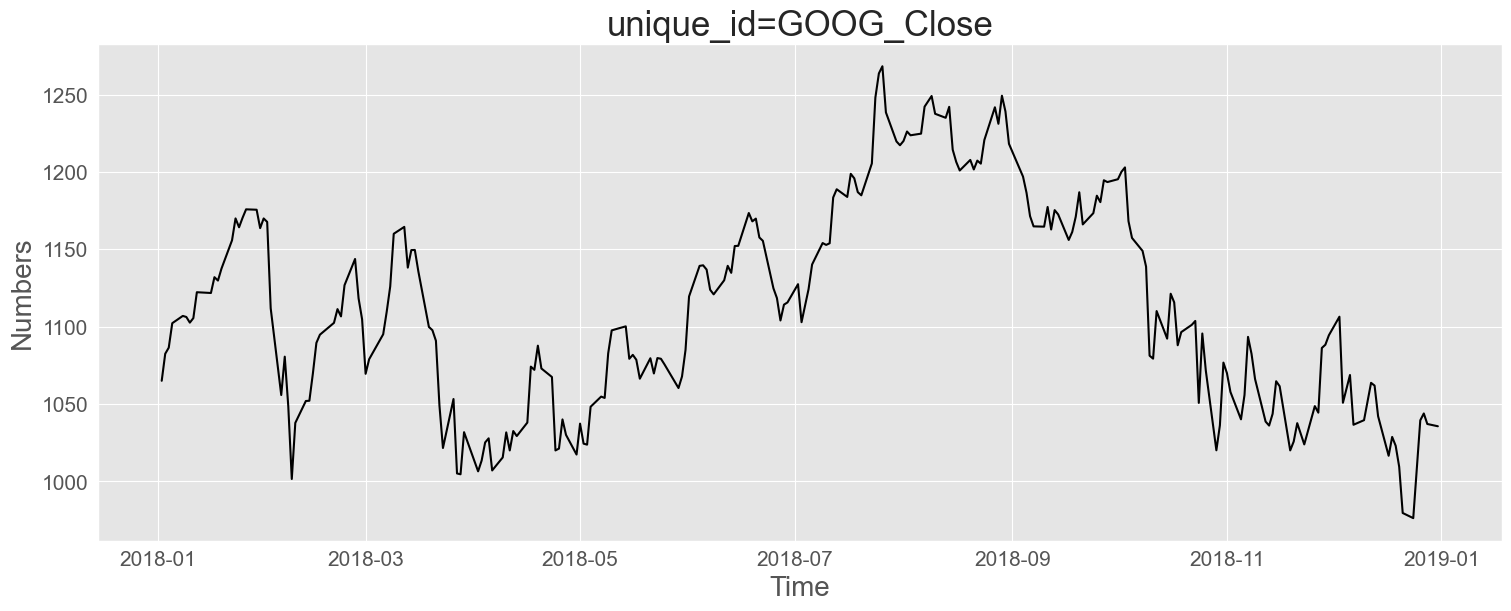

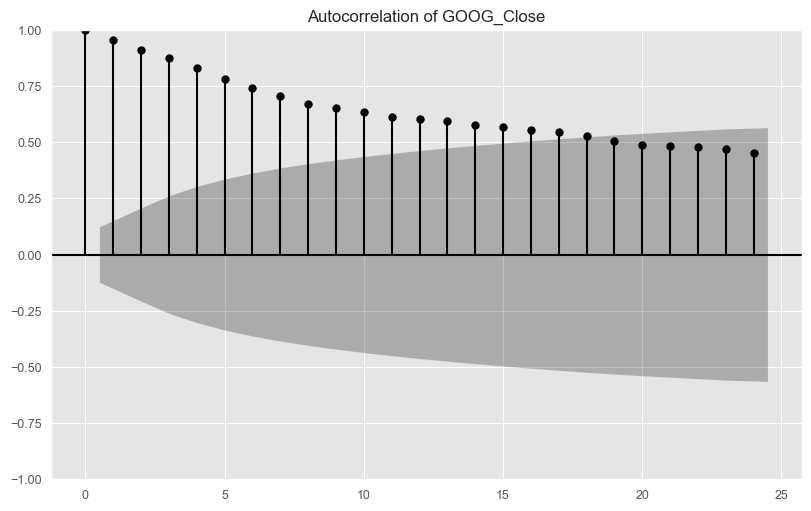

In [34]:
# Answer here
dgoog = (
    pd.read_csv(DATA_DIR / "gafa_stock.csv", parse_dates=["ds"])
    .loc[lambda x: (x["unique_id"] == "GOOG_Close")
        & (x["ds"] >= "2018")
    ]
    .assign(
        trading_day=lambda x: np.arange(1, len(x) + 1),
        diff=lambda x: x["y"].diff(),
    )
    .set_index("trading_day")
)

fig = plot_series(dgoog, time_col='ds', engine='matplotlib') 
for ax in fig.axes:
    ax.set_xlabel('Time')
    ax.set_ylabel('Numbers')
display(fig)


fig2 = plot_acf(x=dgoog['y'], title="Autocorrelation of GOOG_Close")
plt.show()

**Tại sao lại cần Re-index?**
- Toán học của Time Series đòi hỏi khoảng cách thời gian phải đều nhau tuyệt đối:

Các hàm như lấy sai phân (diff()) hay tính tự tương quan (ACF) hoạt động dựa trên vị trí của dòng (dòng hiện tại trừ dòng trước đó). Nếu dữ liệu của bạn bị thiếu mất một tháng (ví dụ: nhảy từ Tháng 1 thẳng sang Tháng 3), lệnh .diff() sẽ lấy Tháng 3 trừ đi Tháng 1. Điều này làm sai lệch hoàn toàn ý nghĩa của sai phân bậc 1 (vốn phải là Tháng 3 trừ Tháng 2). Việc re-index đảm bảo rằng mọi khoảng trống thời gian đều được lấp đầy (bằng NaN hoặc interpolate) để tính toán chính xác.

- Lập chỉ mục thời gian (Time-based indexing):

Khi cột thời gian được chuyển thành Index, Pandas sẽ được "mở khóa" các tính năng trích xuất dữ liệu cực kỳ mạnh mẽ như .loc['1990':'1995'] hoặc nhóm theo năm/tháng .resample('Y').sum().

- Tránh lỗi biểu đồ:

Như bạn đã gặp ở phần trước, nếu index bị lộn xộn hoặc không được sắp xếp theo thời gian, Matplotlib sẽ vẽ các đường nối chéo ngoằn ngoèo đâm xuyên qua nhau.